# M2 — Cleaning, Preprocessing & Merging
**Role:** Member 2 (M2) · **Rubric item:** Cleaning and preprocessing (3 marks)

## 1. M2 Objective
Turn four raw files into **one clean, validated, daily merged dataset** (`merged_daily_clean_m2.csv`) that M3 (EDA) and M4 (target / features / split) can use directly.

```
raw OpenAQ sensor-days ──► cleaning ──► station-day (PM2.5, PM10 columns) ──► city-day ─┐
Open-Meteo daily weather ──► cleaning ───────────────────────────────────────────────────┼─► merge on date ─► validation ─► merged_daily_clean_m2.csv
festival / calendar ──────► cleaning ───────────────────────────────────────────────────┘
```

**Strict boundary:** no EDA, no target definition, no lag/rolling features, no models. Those belong to M3/M4/M5.
Every number in this notebook (and in `M2_report.md`) is computed by the code below — nothing is typed in by hand.

## 2. Load datasets
The notebook looks for the four files in `D:\downloads` first (your original paths) and falls back to the upload folder this notebook was executed in. The calendar file is `cal (1).csv` on your PC (it appears as `cal__1_.csv` after upload — both names are accepted).

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)

CANDIDATE_DIRS = [Path(r"D:\downloads"), Path("/mnt/user-data/uploads"), Path(".")]
FILES = {
    "openaq":    ["openaq_sensor_days_raw.csv"],
    "calendar":  ["cal (1).csv", "cal__1_.csv", "calendar.csv"],
    "weather":   ["weather_daily.csv"],
    "locations": ["openaq_locations.csv"],
}
def find_file(names):
    for d in CANDIDATE_DIRS:
        for n in names:
            if (d / n).exists():
                return d / n
    raise FileNotFoundError(names)

PATHS = {k: find_file(v) for k, v in FILES.items()}
OUT_DIR = Path("/mnt/user-data/outputs") if Path("/mnt/user-data/outputs").exists() else Path(".")

# ---- documented cleaning parameters (see Section 4 for justification) ----
MIN_OBS_FRACTION = 16 / 24      # CPCB: >=16 h of data needed for a 24-h value
SENTINEL_LOW, SENTINEL_HIGH = -9999, 9999   # placeholder codes seen in min/max
EXTREME_QUANTILE = 0.999        # data-driven FLAG (not a deletion rule)
CITY_NAME_KEYWORD = "delhi"     # stations whose name contains this form the city aggregate

oq_raw  = pd.read_csv(PATHS["openaq"])
cal_raw = pd.read_csv(PATHS["calendar"])
wx_raw  = pd.read_csv(PATHS["weather"])
loc_raw = pd.read_csv(PATHS["locations"])

raw_sizes = pd.DataFrame(
    {"file": [PATHS[k].name for k in ["openaq", "calendar", "weather", "locations"]],
     "rows": [len(oq_raw), len(cal_raw), len(wx_raw), len(loc_raw)],
     "columns": [oq_raw.shape[1], cal_raw.shape[1], wx_raw.shape[1], loc_raw.shape[1]]},
    index=["OpenAQ sensor-days", "Calendar", "Open-Meteo weather", "OpenAQ locations"])
print("Source paths:"); [print("  ", k, "->", v) for k, v in PATHS.items()]
print("Output dir :", OUT_DIR.resolve())
raw_sizes

Source paths:
   openaq -> /mnt/user-data/uploads/openaq_sensor_days_raw.csv
   calendar -> /mnt/user-data/uploads/cal__1_.csv
   weather -> /mnt/user-data/uploads/weather_daily.csv
   locations -> /mnt/user-data/uploads/openaq_locations.csv
Output dir : /mnt/user-data/outputs


,file,rows,columns
OpenAQ sensor-days,openaq_sensor_days_raw.csv,97220,14
Calendar,cal__1_.csv,3195,7
Open-Meteo weather,weather_daily.csv,3195,13
OpenAQ locations,openaq_locations.csv,96,7


## 3. Initial data-quality inspection
Each file is profiled **before** anything is changed: shape, dtypes, missing values, duplicate rows / keys, date range, units and sentinel values.

In [2]:
def profile(df, name, date_col=None):
    print("=" * 90); print(name, "| shape:", df.shape)
    print("-- dtypes / missing --")
    out = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(), "n_unique": df.nunique()})
    print(out.to_string())
    print("duplicate full rows:", int(df.duplicated().sum()))
    if date_col:
        d = pd.to_datetime(df[date_col], errors="coerce")
        print(f"date range: {d.min().date()} -> {d.max().date()} | unparseable dates: {int(d.isna().sum())}")

profile(oq_raw,  "OpenAQ sensor-days (raw)", "date")
profile(loc_raw, "OpenAQ locations (raw)")
profile(wx_raw,  "Open-Meteo weather (raw)", "date")
profile(cal_raw, "Festival / calendar (raw)", "date")

OpenAQ sensor-days (raw) | shape: (97220, 14)
-- dtypes / missing --
                    dtype  missing  n_unique
location_id         int64        0        35
location_name         str        0        35
sensor_id           int64        0       136
parameter             str        0         2
units                 str        0         1
date                  str        0      3133
value_avg         float64       82      1940
min               float64       82     20973
max               float64       82     27322
sd                float64     3691     90343
expected_count      int64        0         1
observed_count      int64        0        48
percent_complete  float64        0        48
retrieved_at          str        0         1
duplicate full rows: 0
date range: 2018-01-01 -> 2026-09-29 | unparseable dates: 0
OpenAQ locations (raw) | shape: (96, 7)
-- dtypes / missing --
                  dtype  missing  n_unique
location_id       int64        0        96
location_name       str 

In [3]:
# ---------- OpenAQ specifics ----------
issues = {}
oq_chk = oq_raw.copy()
oq_chk["date_dt"] = pd.to_datetime(oq_chk["date"])
issues["oq_rows"] = len(oq_chk)
issues["oq_missing_value_avg"] = int(oq_chk["value_avg"].isna().sum())
issues["oq_negative_value_avg"] = int((oq_chk["value_avg"] < 0).sum())
issues["oq_negative_hourly_min_but_avg_nonneg"] = int(((oq_chk["min"] < 0) & (oq_chk["value_avg"] >= 0)).sum())
issues["oq_zero_value_avg"] = int((oq_chk["value_avg"] == 0).sum())
issues["oq_sentinel_rows"] = int(((oq_chk["min"] <= SENTINEL_LOW) | (oq_chk["max"] >= SENTINEL_HIGH)).sum())
issues["oq_dup_full_rows"] = int(oq_chk.duplicated().sum())
issues["oq_dup_sensor_date_keys"] = int(oq_chk.duplicated(["location_id", "sensor_id", "parameter", "date"]).sum())
issues["oq_dup_station_param_date_keys"] = int(oq_chk.duplicated(["location_id", "parameter", "date"]).sum())
issues["oq_obs_gt_expected"] = int((oq_chk["observed_count"] > oq_chk["expected_count"]).sum())
issues["oq_pct_complete_gt_100"] = int((oq_chk["percent_complete"] > 100).sum())
issues["oq_obs_lt_16"] = int((oq_chk["observed_count"] < 16).sum())
issues["oq_sd_gt_1e4"] = int((oq_chk["sd"] > 1e4).sum())
issues["oq_avg_outside_min_max_tol10"] = int(((oq_chk["value_avg"] < oq_chk["min"] - 10) | (oq_chk["value_avg"] > oq_chk["max"] + 10)).sum())

print("Units          :", oq_chk["units"].unique().tolist())
print("Parameters     :", oq_chk["parameter"].value_counts().to_dict())
print("expected_count :", oq_chk["expected_count"].unique().tolist())
print("Stations       :", oq_chk["location_id"].nunique(), "| sensors:", oq_chk["sensor_id"].nunique())
print("Each sensor maps to exactly one station/parameter:",
      bool((oq_chk.groupby("sensor_id")[["location_id", "parameter"]].nunique() == 1).all().all()))
print("Each station_id maps to one name:", bool((oq_chk.groupby("location_id")["location_name"].nunique() == 1).all()))
print("Stations missing from locations file:", sorted(set(oq_chk.location_id) - set(loc_raw.location_id)))
print("Min / max raw value_avg:", oq_chk["value_avg"].min(), "/", oq_chk["value_avg"].max())
print("Placeholder-like min values (<= -9999):", int((oq_chk["min"] <= SENTINEL_LOW).sum()),
      "| placeholder-like max (>= 9999):", int((oq_chk["max"] >= SENTINEL_HIGH).sum()))
print()
print("Rows per calendar year (raw):")
print(oq_chk.groupby(oq_chk["date_dt"].dt.year).size().to_string())
print()
print("OpenAQ issue counts:"); print(json.dumps(issues, indent=1))
# dates must be ISO yyyy-mm-dd in the SOURCE text (guards against day-first / month-first misreads)
iso = r"^\d{4}-\d{2}-\d{2}$"
iso_ok = {n: bool(d["date"].astype(str).str.match(iso).all()) for n, d in [("openaq", oq_raw), ("weather", wx_raw), ("calendar", cal_raw)]}
print("\nAll source dates are ISO yyyy-mm-dd text:", iso_ok)
assert all(iso_ok.values())

Units          : ['µg/m³']
Parameters     : {'pm25': 50439, 'pm10': 46781}
expected_count : [24]
Stations       : 35 | sensors: 136
Each sensor maps to exactly one station/parameter: True
Each station_id maps to one name: True
Stations missing from locations file: []
Min / max raw value_avg: -4210.0 / 2640.0
Placeholder-like min values (<= -9999): 4 | placeholder-like max (>= 9999): 20

Rows per calendar year (raw):
date_dt
2018     6063
2019    10167
2020    17831
2021    12796
2022    10261
2023      321
2024      366
2025    21470
2026    17945

OpenAQ issue counts:
{
 "oq_rows": 97220,
 "oq_missing_value_avg": 82,
 "oq_negative_value_avg": 32,
 "oq_negative_hourly_min_but_avg_nonneg": 602,
 "oq_zero_value_avg": 328,
 "oq_sentinel_rows": 24,
 "oq_dup_full_rows": 0,
 "oq_dup_sensor_date_keys": 0,
 "oq_dup_station_param_date_keys": 0,
 "oq_obs_gt_expected": 34579,
 "oq_pct_complete_gt_100": 34579,
 "oq_obs_lt_16": 19443,
 "oq_sd_gt_1e4": 8,
 "oq_avg_outside_min_max_tol10": 0
}

All so

In [4]:
# ---------- Weather / calendar specifics ----------
wx_chk, cal_chk = wx_raw.copy(), cal_raw.copy()
for d in (wx_chk, cal_chk):
    d["date"] = pd.to_datetime(d["date"])
full_range = pd.date_range(min(wx_chk.date.min(), cal_chk.date.min()), max(wx_chk.date.max(), cal_chk.date.max()), freq="D")
for name, d in [("weather", wx_chk), ("calendar", cal_chk)]:
    print(f"{name}: rows={len(d)}, unique dates={d.date.nunique()}, duplicate dates={int(d.date.duplicated().sum())}, "
          f"missing dates in range={len(full_range.difference(d.date))}, sorted={d.date.is_monotonic_increasing}")
print("Weather summary (min/max):"); print(wx_chk.describe().T[["min", "max"]].to_string())
print("Calendar season values:", cal_chk.season.value_counts().to_dict())
print("Calendar days_from_diwali==0 dates:", cal_chk.loc[cal_chk.days_from_diwali == 0, "date"].dt.date.astype(str).tolist())
print("Locations: rows =", len(loc_raw), "| unique ids =", loc_raw.location_id.nunique(), "| timezones =", loc_raw.timezone.unique().tolist())

weather: rows=3195, unique dates=3195, duplicate dates=0, missing dates in range=0, sorted=True
calendar: rows=3195, unique dates=3195, duplicate dates=0, missing dates in range=0, sorted=True
Weather summary (min/max):
                                 min                  max
date             2018-01-01 00:00:00  2026-09-30 00:00:00
temp_mean                   6.683333            39.220833
temp_min                         2.0                 34.5
temp_max                        12.8                 46.0
humidity_mean                  10.25            95.833333
dewpoint_mean                   -3.6            26.883333
wind_speed_mean               0.5675             6.380417
wind_gust_max                    3.1                 22.2
pressure_mean             967.445833                998.6
precip_sum                       0.0                122.7
cloud_mean                       0.0                100.0
hours                           24.0                 24.0
wind_dir_deg              

**What the inspection shows (all counts printed above):**
- OpenAQ values are all in **µg/m³** and only **PM2.5 and PM10** exist (no NO2/SO2/CO/O3).
- There are **missing** daily values, **negative** averages, and **placeholder codes** (e.g. min = −9999, max = 9999.9) that poison the daily average.
- `observed_count` often **exceeds** `expected_count` (24) and `percent_complete` goes up to 200 % → those sensors report more often than hourly, so `percent_complete` cannot be used raw.
- `sd` contains absurd values (up to ~10¹⁴) → not trustworthy, so it is not carried forward.
- No exact duplicate rows and no duplicate keys in OpenAQ; weather and calendar already have one row per day.
- Pollution coverage is **very uneven across years** (checked formally in Section 10).

## 4. OpenAQ cleaning
Rules are applied **in order**; each step is logged to `M2_cleaning_log.csv` with rows before/after and a justification.

| Rule | Action | Justification |
|---|---|---|
| Standardise dtypes, names | change | merge keys must be clean `datetime64` / stripped strings |
| Exact duplicates, duplicate sensor-date keys | drop | a sensor-day must appear once |
| Missing `value_avg` | drop | no measurement exists; **not** imputed (would fabricate target data) |
| Placeholder codes (`min ≤ −9999` or `max ≥ 9999`) | drop | the code is inside the day's readings, so the daily mean is contaminated |
| Negative `value_avg` | drop | a concentration cannot be negative |
| Negative hourly `min` but mean ≥ 0 | **flag only** | mean is still physically valid; small negatives are normal instrument noise |
| Completeness `observed_count / expected_count < 16/24` | drop | CPCB requires ≥16 h of data to compute a 24-h value |
| Stuck sensor (`min == max` over ≥16 readings; includes every exact-zero day) | drop | a full day of identical readings is a frozen instrument; diagnosed: all exact-zero days had min = max = 0 while other sensors read far above zero that day (median printed in 4.8) |
| Analyzer ceiling codes (a daily `max ≥ 900` that repeats on ≥5 dates at the same station, e.g. 999.99, 1000, 1985, 4985) | drop | a saturated reading is inside the day's readings, same logic as the 9999.9 placeholder |
| Peer-inconsistent day (> 8× the median of the other Delhi stations the same day, value > 150, ≥ 5 peers) | drop | a local spike with no city-wide event; real city-wide events lift all stations together, so their ratio stays low and they are kept (ratio distribution printed in 4.10) |
| Remaining extreme positives | **flag only** (above the 99.9th percentile of each pollutant; plus `flag_peer_suspect` for 5–8× peers) | extremes in Delhi can be real (Diwali / crop-burning); never deleted blindly. No blanket cap is used (see 4b) |

**External standard used:** CPCB's National AQI methodology — a pollutant sub-index needs ≥16 hours of data in the day (see AQI section for sources).
**Caveat:** several sensors report sub-hourly (`observed_count` up to 48). For those, 16 readings may span < 16 h, so the completeness rule is slightly lenient for them. These rows are marked with `*_obs_count` so M3/M4 can tighten it if wanted.

In [5]:
cleaning_log = []
row_trace = []   # (label, rows) for the simple QC chart
def log_step(step, dataset, before, after, changed, reason, justification):
    cleaning_log.append({"cleaning_step": step, "dataset_affected": dataset, "rows_before": int(before),
                         "rows_after": int(after), "rows_removed_or_changed": int(changed),
                         "reason": reason, "justification": justification})

oq = oq_raw.copy()
row_trace.append(("raw", len(oq)))

# 4.1 standardise types / strings
name_changes = int((oq["location_name"] != oq["location_name"].str.strip()).sum())
oq["date"] = pd.to_datetime(oq["date"], format="%Y-%m-%d", errors="raise")
oq["parameter"] = oq["parameter"].str.strip().str.lower()
oq["location_name"] = oq["location_name"].str.strip()
assert oq["units"].nunique() == 1 and oq["units"].iloc[0] == "µg/m³", "mixed units"
log_step("Standardise dtypes and strings", "OpenAQ sensor-days", len(oq), len(oq), name_changes,
         "date was text; parameter/name strings need to be consistent",
         "Proper datetime keys are needed for merging; all rows already share a single unit (µg/m³) so no unit conversion was needed")

# 4.2 duplicates
b = len(oq); oq = oq.drop_duplicates(); a = len(oq)
log_step("Drop exact duplicate rows", "OpenAQ sensor-days", b, a, b - a, "duplicate rows", "Identical rows add no information")
key = ["location_id", "sensor_id", "parameter", "date"]
b = len(oq); oq = oq.sort_values("retrieved_at").drop_duplicates(key, keep="last"); a = len(oq)
log_step("Drop duplicate sensor-date-parameter keys", "OpenAQ sensor-days", b, a, b - a, "same sensor/day recorded twice",
         "One value per sensor-day is required before aggregation (none found in this file, rule kept for reproducibility)")
row_trace.append(("after de-dup", len(oq)))

# 4.3 missing
b = len(oq); oq = oq[oq["value_avg"].notna()].copy(); a = len(oq)
log_step("Drop rows with missing daily mean", "OpenAQ sensor-days", b, a, b - a, "value_avg is NaN",
         "No measurement exists; imputing would fabricate pollution data. The date stays in the final dataset if no other station has data")
row_trace.append(("missing value removed", len(oq)))

# 4.4 placeholder / sentinel contamination
sent = (oq["min"] <= SENTINEL_LOW) | (oq["max"] >= SENTINEL_HIGH)
b = len(oq); oq = oq[~sent].copy(); a = len(oq)
log_step("Drop placeholder-contaminated days (min<=-9999 or max>=9999)", "OpenAQ sensor-days", b, a, b - a,
         "sensor error codes (-9999 / 9999.9) were averaged into the daily mean",
         "The daily mean is arithmetically contaminated and cannot be repaired from the summary columns")
row_trace.append(("placeholder removed", len(oq)))

# 4.5 negative concentrations
neg = oq["value_avg"] < 0
b = len(oq); oq = oq[~neg].copy(); a = len(oq)
log_step("Drop negative daily mean", "OpenAQ sensor-days", b, a, b - a, "negative PM concentration is physically impossible",
         "Clearly invalid values removed; extreme POSITIVE values are deliberately kept (flagged instead)")
row_trace.append(("negative removed", len(oq)))

pre16 = oq.copy()   # kept for the network diagnostics in 4b (after missing/placeholder/negative, before completeness)

# 4.6 flag-only rule
oq["flag_neg_hourly_min"] = (oq["min"] < 0).astype(int)
log_step("Flag negative hourly minimum (kept)", "OpenAQ sensor-days", len(oq), len(oq), oq["flag_neg_hourly_min"].sum(),
         "min < 0 while daily mean >= 0", "Daily mean is valid; flag lets downstream users test sensitivity")

# 4.7 completeness (CPCB 16-hour rule)
oq["coverage_pct"] = (oq["observed_count"] / oq["expected_count"] * 100).clip(upper=100).round(1)
oq["flag_subhourly"] = (oq["observed_count"] > oq["expected_count"]).astype(int)
log_step("Flag sub-hourly sensor-days (kept)", "OpenAQ sensor-days", len(oq), len(oq), oq["flag_subhourly"].sum(),
         "observed_count > expected_count (percent_complete > 100)", "Sensor reports more often than hourly; raw percent_complete is therefore not capped-safe, coverage_pct is capped at 100")
low = (oq["observed_count"] / oq["expected_count"]) < MIN_OBS_FRACTION
b = len(oq); oq = oq[~low].copy(); a = len(oq)
log_step("Drop incomplete sensor-days (<16 of 24 expected readings)", "OpenAQ sensor-days", b, a, b - a,
         "fewer than 16 readings in the day",
         "CPCB National AQI requires >=16 h of data for a 24-hour value; a 2-reading 'daily mean' is not a daily mean")
row_trace.append(("completeness >=16/24", len(oq)))
post16 = oq.copy()   # for the extreme-value diagnostic in 4b

# 4.8 stuck-sensor days (every reading identical) -> includes all exact-zero days
peer_ref = (oq[(oq["min"] != oq["max"]) & (oq["value_avg"] > 0)].groupby(["date", "parameter"])["value_avg"].median().rename("peer_med_all").reset_index())
def peer_level(rows):   # median over the given sensor-days of the all-station median (same date and pollutant)
    return float(rows[["date", "parameter"]].merge(peer_ref, how="left", on=["date", "parameter"])["peer_med_all"].median())
stuck = oq["min"] == oq["max"]
stuck_zero_peer = peer_level(oq[stuck & (oq["value_avg"] == 0)])
print(f"Exact-zero stuck days: median level of all other sensors on those dates = {stuck_zero_peer:.0f} ug/m3")
n_stuck_zero = int((stuck & (oq["value_avg"] == 0)).sum())
b = len(oq); oq = oq[~stuck].copy(); a = len(oq)
log_step("Drop stuck-sensor days (min == max over >=16 readings)", "OpenAQ sensor-days", b, a, b - a,
         f"all readings identical (of which {n_stuck_zero} are exact-zero days)",
         f"Ambient PM cannot be constant for a day; zero days were diagnosed as faults (min=max=0 while other sensors read a median of {stuck_zero_peer:.0f} ug/m3 on those dates)")
row_trace.append(("stuck sensor removed", len(oq)))
assert (oq["value_avg"] == 0).sum() == 0

# 4.9 analyzer ceiling codes: same exact daily max >=900 repeating on >=5 dates at the same station
rec = oq[oq["max"] >= 900].groupby(["location_id", "parameter", "max"])["date"].nunique().reset_index()
CEIL_CODES = sorted(rec.loc[rec["date"] >= 5, "max"].unique().tolist())
ceil = oq["max"].isin(CEIL_CODES)
print("Detected ceiling codes (exact daily max repeating on >=5 dates at one station):", CEIL_CODES)
ceil_rows = oq[ceil].copy(); ceil_peer = peer_level(ceil_rows)
print(f"Ceiling-code days: {len(ceil_rows)}; median level of all other sensors on those dates = {ceil_peer:.0f} ug/m3")
b = len(oq); oq = oq[~ceil].copy(); a = len(oq)
log_step("Drop days containing an analyzer ceiling code", "OpenAQ sensor-days", b, a, b - a,
         f"daily max equals a repeating saturation value {CEIL_CODES}",
         f"A saturated reading is averaged into the day's mean (same logic as the 9999.9 placeholder); on these dates the median of all sensors was {ceil_peer:.0f} ug/m3")
row_trace.append(("ceiling codes removed", len(oq)))

# 4.10 peer-consistency (Delhi stations vs the other Delhi stations on the same day and pollutant)
PEER_MIN, PEER_DROP_X, PEER_FLAG_X, PEER_FLOOR = 5, 8, 5, 150
is_delhi_row = oq["location_name"].str.lower().str.contains(CITY_NAME_KEYWORD)
oq["peer_med"] = np.nan; oq["peer_n"] = 0
for (dt_, par_), g in oq[is_delhi_row].groupby(["date", "parameter"]):
    if len(g) < PEER_MIN + 1:
        continue
    v = g["value_avg"].values
    for i, ix in enumerate(g.index):
        oq.at[ix, "peer_med"] = np.median(np.delete(v, i)); oq.at[ix, "peer_n"] = len(v) - 1
oq["peer_ratio"] = oq["value_avg"] / oq["peer_med"]
print("Peer-ratio distribution (Delhi sensor-days with >=5 peers):"); print(oq["peer_ratio"].describe(percentiles=[.5, .9, .99, .999]).round(2).to_string())
peer_sens = pd.DataFrame({f">{k}x": [int(((oq.peer_ratio > k) & (oq.value_avg > PEER_FLOOR) & (oq.parameter == p)).sum()) for p in ["pm25", "pm10"]] for k in (3, 5, 8, 10)}, index=["pm25", "pm10"])
print("\nSensitivity of the peer rule (rows that would be dropped):"); print(peer_sens.to_string())
peer_bad = (oq["peer_ratio"] > PEER_DROP_X) & (oq["value_avg"] > PEER_FLOOR)
oq["flag_peer_suspect"] = (((oq["peer_ratio"] > PEER_FLAG_X) & (oq["value_avg"] > PEER_FLOOR)) & ~peer_bad).astype(int)
peer_rows = oq[peer_bad].copy()
b = len(oq); oq = oq[~peer_bad].copy(); a = len(oq)
log_step(f"Drop peer-inconsistent days (>{PEER_DROP_X}x peer median, value>{PEER_FLOOR})", "OpenAQ sensor-days", b, a, b - a,
         "one station far above all other Delhi stations the same day",
         "Local sensor spikes (see the hourly max vs peer level printed in 4b) rather than city-wide events, which lift every station together and keep the ratio low; needs >=5 peers, so single-station days are protected by the stuck/ceiling rules instead")
log_step(f"Flag peer-suspect days ({PEER_FLAG_X}-{PEER_DROP_X}x peers; kept)", "OpenAQ sensor-days", len(oq), len(oq), oq["flag_peer_suspect"].sum(),
         "moderately inconsistent with peers", "Not clearly invalid, so flagged not removed")
row_trace.append(("peer-inconsistent removed", len(oq)))
oq = oq.drop(columns=["peer_med", "peer_n", "peer_ratio"])

# 4.11 remaining extreme positives -> FLAG (data-driven, not an official limit)
extreme_thr = oq.groupby("parameter")["value_avg"].quantile(EXTREME_QUANTILE)
oq["flag_extreme"] = (oq["value_avg"] > oq["parameter"].map(extreme_thr)).astype(int)
log_step("Flag extreme positive values (kept)", "OpenAQ sensor-days", len(oq), len(oq), oq["flag_extreme"].sum(),
         "value above the 99.9th percentile of its pollutant",
         "No official upper plausibility limit exists, so none was invented; statistical flag only, nothing deleted")

# 4.12 station consistency + coordinates
loc = loc_raw.copy()
loc["location_name"] = loc["location_name"].str.strip()
name_ok = oq[["location_id", "location_name"]].drop_duplicates().merge(loc[["location_id", "location_name"]], on="location_id", how="left", suffixes=("_oq", "_loc"))
print("Station name mismatches vs locations file:", int((name_ok.location_name_oq != name_ok.location_name_loc).sum()))
print("Stations kept:", oq.location_id.nunique(), "| extreme thresholds (ug/m3):", extreme_thr.round(1).to_dict())
log_step("Check station/location consistency", "OpenAQ sensor-days + locations", len(oq), len(oq), 0,
         "ids/names must agree across files", "All station ids exist in openaq_locations.csv and names match; coordinates attached from that file")
row_trace.append(("final cleaned", len(oq)))
print("\nOpenAQ rows: raw", len(oq_raw), "-> cleaned", len(oq), f"({len(oq_raw)-len(oq)} removed)")
pd.DataFrame(row_trace, columns=["stage", "rows"])

Exact-zero stuck days: median level of all other sensors on those dates = 83 ug/m3
Detected ceiling codes (exact daily max repeating on >=5 dates at one station): [999.99, 1000.0, 1191.0, 1985.0, 1989.0, 2000.0, 3490.0, 4985.0, 4996.0]
Ceiling-code days: 283; median level of all other sensors on those dates = 158 ug/m3


Peer-ratio distribution (Delhi sensor-days with >=5 peers):
count    70560.00
mean         1.04
std          0.35
min          0.00
50%          1.00
90%          1.38
99%          2.05
99.9%        3.50
max         22.52

Sensitivity of the peer rule (rows that would be dropped):
      >3x  >5x  >8x  >10x
pm25   43   19   11     9
pm10   19    2    0     0
Station name mismatches vs locations file: 0
Stations kept: 35 | extreme thresholds (ug/m3): {'pm10': 768.3, 'pm25': 526.0}

OpenAQ rows: raw 97220 -> cleaned 77118 (20102 removed)


,stage,rows
0,raw,97220
1,after de-dup,97220
2,missing value removed,97138
3,placeholder removed,97114
4,negative removed,97086
5,completeness >=16/24,77670
6,stuck sensor removed,77412
7,ceiling codes removed,77129
8,peer-inconsistent removed,77118
9,final cleaned,77118


## 4b. Network and extreme-value diagnostics (reviewer concerns checked against the data)
Three questions, each answered with numbers before deciding whether to change anything:
1. **Is the 16-reading rule what makes the station count collapse?** (compare stations per calendar day at each stage, and at looser thresholds)
2. **Are near-duplicate station feeds double counted?** (500 m distance check on the stations that are actually in the data)
3. **Would a blanket concentration cap be better than the ceiling/stuck/peer rules?**

In [6]:
all_days = pd.date_range("2018-01-01", "2026-09-30", freq="D")
def delhi_only(d): return d[d["location_name"].str.lower().str.contains(CITY_NAME_KEYWORD)]
def stations_per_day(d, par="pm25"):
    x = delhi_only(d[d.parameter == par]).groupby("date")["location_id"].nunique().reindex(all_days).fillna(0)
    return x
def summarise(d):
    x = stations_per_day(d); yr_ = x.groupby(x.index.year)
    return pd.DataFrame({"mean_stations_per_day": yr_.mean().round(1), "pct_days_ge3_stations": yr_.apply(lambda v: (v >= 3).mean() * 100).round(1)})

raw_valid = oq_raw[oq_raw["value_avg"].notna()].copy(); raw_valid["date"] = pd.to_datetime(raw_valid["date"])
stage_tbl = pd.concat({"raw file (any value)": summarise(raw_valid), "after missing/placeholder/negative": summarise(pre16),
                       "after 16-reading rule": summarise(post16), "final (all rules)": summarise(oq)}, axis=1)
print("PM2.5, Delhi stations - stations per calendar day by stage (days with no station count as 0):")
print(stage_tbl.to_string())

# months in the RAW file where at most one Delhi station reported at all -> source gaps, not cleaning
rm = delhi_only(raw_valid[raw_valid.parameter == "pm25"]).groupby(raw_valid["date"].dt.to_period("M"))["location_id"].nunique()
rm = rm.reindex(pd.period_range("2018-01", "2026-09", freq="M")).fillna(0)
thin_months = rm[rm <= 1]
print(f"\nMonths where the RAW file has <=1 Delhi PM2.5 station: {len(thin_months)} of {len(rm)} -> {thin_months.index.astype(str).tolist()}")

# threshold sensitivity (diagnostic only; the CPCB 16/24 rule is kept)
thr_tbl = {}
for k in (8, 12, 16):
    x = stations_per_day(pre16[pre16.observed_count >= k]); thr_tbl[f">= {k} readings"] = x.groupby(x.index.year).mean().round(1)
thr_tbl = pd.DataFrame(thr_tbl)
print("\nMean Delhi PM2.5 stations per calendar day under looser completeness thresholds:"); print(thr_tbl.to_string())

# sub-hourly sensitivity: sensors whose 90th-percentile daily count exceeds 24 are treated as 2 readings/hour
q90 = oq_raw.groupby("sensor_id")["observed_count"].quantile(.9); sub_sensors = set(q90[q90 > 24].index)
need = np.where(post16["sensor_id"].isin(sub_sensors), 32, 16)
strict = post16[post16["observed_count"] >= need]
print(f"\nSub-hourly sensitivity: {int(post16.sensor_id.isin(sub_sensors).sum())} of {len(post16)} kept sensor-days are from sub-hourly sensors; "
      f"{len(post16) - len(strict)} would fail a '16 hours-equivalent' (32 readings) rule.")
sub_tbl = pd.concat({"16 readings (applied)": summarise(post16)["mean_stations_per_day"], "16 h-equivalent (diagnostic)": summarise(strict)["mean_stations_per_day"]}, axis=1)
print(sub_tbl.to_string())

# ---- duplicate station feeds
locs_in = loc[loc.location_id.isin(oq_raw.location_id.unique())].reset_index(drop=True)
def hav_m(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2); dphi = p2 - p1; dl = np.radians(lon2 - lon1)
    h = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * 6371000 * np.arcsin(np.sqrt(h))
def close_pairs(L, thr_m):
    out = []
    for i in range(len(L)):
        for j in range(i + 1, len(L)):
            d_ = hav_m(L.latitude[i], L.longitude[i], L.latitude[j], L.longitude[j])
            if d_ < thr_m: out.append((L.location_id[i], L.location_id[j], L.location_name[j], round(float(d_))))
    return pd.DataFrame(out, columns=["id_a", "id_b", "name_b", "distance_m"])
dup_in_data = close_pairs(locs_in, 500)
dup_in_file = close_pairs(loc.reset_index(drop=True), 500)
ids_in_data = set(oq_raw.location_id.unique())
dup_not_loaded = dup_in_file[~(dup_in_file.id_a.isin(ids_in_data) & dup_in_file.id_b.isin(ids_in_data))]
print(f"\nStation pairs closer than 500 m among the {len(locs_in)} stations present in the sensor data: {len(dup_in_data)}")
print(f"Pairs closer than 500 m in openaq_locations.csv overall: {len(dup_in_file)} (none of them has BOTH feeds in the sensor data: {len(dup_not_loaded) == len(dup_in_file)})")
log_step("Check near-duplicate station feeds (<500 m)", "OpenAQ locations vs sensor-days", len(locs_in), len(locs_in), len(dup_in_data),
         "same physical station under two ids would be counted twice in the city mean",
         f"{len(dup_in_data)} close pairs among stations present in the data (nearest pair is {int(min(hav_m(a.latitude,a.longitude,b.latitude,b.longitude) for a in locs_in.itertuples() for b in locs_in.itertuples() if a.location_id < b.location_id))} m apart); duplicate ids exist only in the locations file and were never loaded")

# ---- is a blanket cap better? what would a >1000 ug/m3 cap hit?
cap_hits = post16[post16.value_avg > 1000].copy()
cap_hits["kept_by_rules"] = cap_hits.set_index(["location_id", "sensor_id", "date"]).index.isin(oq.set_index(["location_id", "sensor_id", "date"]).index)
print(f"\nSensor-days above 1000 ug/m3 after the completeness rule: {len(cap_hits)} | removed by stuck/ceiling/peer rules: {int((~cap_hits.kept_by_rules).sum())} | still kept: {int(cap_hits.kept_by_rules.sum())}")
print(cap_hits[cap_hits.kept_by_rules][["location_name", "parameter", "date", "value_avg"]].to_string(index=False))
print("Max remaining PM2.5 / PM10 daily mean:", oq.groupby("parameter").value_avg.max().to_dict())
kept_cap = cap_hits[cap_hits.kept_by_rules][["date", "parameter"]].merge(peer_ref, how="left", on=["date", "parameter"])
print("Median of ALL sensors on the dates of the >1000 sensor-days the rules keep (high peers => a real city-wide event):", kept_cap["peer_med_all"].round(0).tolist())
n_ceil_below_cap = int((ceil_rows["value_avg"] <= 1000).sum())
print(f"Ceiling-code days with daily mean <= 1000 (a 1000 cap would NOT catch them): {n_ceil_below_cap} of {len(ceil_rows)}")
print("\nPeer-rule drops (hourly max / min vs all-sensor median that day):")
print(peer_rows.merge(peer_ref, how="left", on=["date", "parameter"])[["location_name", "parameter", "date", "value_avg", "min", "max", "peer_med_all"]].round(1).to_string(index=False))

PM2.5, Delhi stations - stations per calendar day by stage (days with no station count as 0):
      raw file (any value)                       after missing/placeholder/negative                       after 16-reading rule                           final (all rules)                      
     mean_stations_per_day pct_days_ge3_stations              mean_stations_per_day pct_days_ge3_stations mean_stations_per_day pct_days_ge3_stations mean_stations_per_day pct_days_ge3_stations
2018                   9.0                  59.7                                9.0                  59.7                   7.0                  46.0                   6.9                  46.0
2019                  13.9                  53.7                               13.9                  53.7                  13.0                  51.2                  12.8                  51.2
2020                  23.2                  98.4                               23.2                  98.4                  16.0   

      16 readings (applied)  16 h-equivalent (diagnostic)
2018                    7.0                           4.0
2019                   13.0                          11.0
2020                   16.0                           9.6
2021                    9.3                           6.5
2022                   10.1                           6.9
2023                    0.9                           0.9
2024                    1.0                           0.8
2025                   26.1                          25.2
2026                   28.4                          27.5



Station pairs closer than 500 m among the 35 stations present in the sensor data: 0
Pairs closer than 500 m in openaq_locations.csv overall: 17 (none of them has BOTH feeds in the sensor data: True)

Sensor-days above 1000 ug/m3 after the completeness rule: 13 | removed by stuck/ceiling/peer rules: 11 | still kept: 2
                location_name parameter       date  value_avg
North Campus, DU, Delhi - IMD      pm10 2018-11-08     1230.0
Vasundhara, Ghaziabad - UPPCB      pm10 2018-11-08     1040.0
Max remaining PM2.5 / PM10 daily mean: {'pm10': 1230.0, 'pm25': 915.0}
Median of ALL sensors on the dates of the >1000 sensor-days the rules keep (high peers => a real city-wide event): [735.0, 735.0]
Ceiling-code days with daily mean <= 1000 (a 1000 cap would NOT catch them): 276 of 283

Peer-rule drops (hourly max / min vs all-sensor median that day):
                         location_name parameter       date  value_avg   min    max  peer_med_all
         North Campus, DU, Delhi - IMD  

**Reading the diagnostics (numbers are printed above):**
- The 16-reading rule is a major cause in **2020–2021** (compare the *raw file* and *after 16-reading rule* columns), but **2022-11 → 2025-01** and a few months in 2018–2019 are gaps in the **source file itself** (the `thin months` list) that no completeness threshold can recover. Looser thresholds (table above) win back only part of the loss, so the CPCB 16-reading rule is **kept**.
- No two stations that are present in the sensor data are within 500 m of each other; the duplicate station ids exist only in `openaq_locations.csv`, so nothing is double counted.
- A blanket 1000 µg/m³ cap is **not used**: it cannot catch saturation days whose mean is below the cap (count printed), and the >1000 sensor-days that the rules keep are listed with the level of all other sensors that day so you can see whether they are city-wide events. The ceiling-code, stuck-sensor and peer rules target the actual faults.
- The sub-hourly check is **diagnostic only**: the file does not say the sensors sample every 30 minutes, so imposing 32 readings would rest on an assumption. The `flag_subhourly` columns remain for M3/M4.

## 5. Pollution aggregation
**raw sensor-day observations → station-day → city-day**

- **Station-day:** group by `station + date + pollutant`. The *mean of sensor daily means* is used, because the daily value is already an average and the sensors are interchangeable measurements of the same station/pollutant. Before trusting that choice the code checks whether any group has more than one sensor (if sensors overlapped, a mean would matter; if not, it is a lossless pass-through). PM2.5 and PM10 are then pivoted into separate columns.
- **City-day:** the **mean across stations** (plus the median, which is robust to station spikes, and the number of stations that contributed). Only stations whose name contains "Delhi" are used for the city aggregate — the file also holds one Ghaziabad and one Gurugram station, which are outside Delhi.
- The number of contributing stations is kept (`*_n_stations`) because the monitoring network changes a lot over time; a city mean from 1 station is not comparable with one from 30.

No predictive features are created here.

In [7]:
grp = ["location_id", "date", "parameter"]
agg = (oq.groupby(grp)
         .agg(value=("value_avg", "mean"), n_sensors=("sensor_id", "nunique"), obs_count=("observed_count", "sum"),
              flag_neg_hourly_min=("flag_neg_hourly_min", "max"), flag_peer_suspect=("flag_peer_suspect", "max"),
              flag_extreme=("flag_extreme", "max"), flag_subhourly=("flag_subhourly", "max"))
         .reset_index())
print("Sensors per station-day-pollutant group:"); print(agg["n_sensors"].value_counts().to_string())
overlap_groups = int((agg["n_sensors"] > 1).sum())
print("-> groups where aggregation actually combines >1 sensor:", overlap_groups)
log_step("Aggregate to station-day-pollutant (mean of sensor means)", "OpenAQ cleaned -> station-day long",
         len(oq), len(agg), len(oq) - len(agg), "one row per station+date+pollutant required",
         f"Sensors never overlap on the same station/day ({overlap_groups} groups with >1 sensor), so the mean is a lossless pass-through")

parts = []
for p in ["pm25", "pm10"]:
    s = (agg[agg.parameter == p].drop(columns=["parameter", "n_sensors"]).set_index(["location_id", "date"]))
    s = s.rename(columns={"value": p})
    s.columns = [p if c == p else f"{p}_{c}" for c in s.columns]
    parts.append(s)
station_day = pd.concat(parts, axis=1).reset_index().sort_values(["location_id", "date"]).reset_index(drop=True)
for c in [c for c in station_day.columns if "flag" in c]:
    station_day[c] = station_day[c].fillna(0).astype(int)
for c in ["pm25_obs_count", "pm10_obs_count"]:
    station_day[c] = station_day[c].astype("Int64")
station_day["flag_pm25_gt_pm10"] = ((station_day["pm25"] > station_day["pm10"])).fillna(False).astype(int)
station_day = station_day.merge(loc[["location_id", "location_name", "latitude", "longitude"]], on="location_id", how="left", validate="many_to_one")
lead = ["location_id", "location_name", "latitude", "longitude", "date"]
station_day = station_day[lead + [c for c in station_day.columns if c not in lead]]
assert not station_day.duplicated(["location_id", "date"]).any()
log_step("Pivot to wide station-day (pm25, pm10 columns)", "station-day", len(agg), len(station_day), len(agg) - len(station_day),
         "PM2.5 and PM10 must be separate columns", "One row per station+date; outer join keeps days where only one pollutant exists")
log_step("Flag PM2.5 > PM10 on the same station-day (kept)", "station-day", len(station_day), len(station_day), station_day["flag_pm25_gt_pm10"].sum(),
         "PM2.5 is a subset of PM10 so PM2.5 > PM10 is physically inconsistent beyond measurement error", "Flagged for transparency, not removed (could be sensor tolerance)")
print("station-day shape:", station_day.shape)
station_day.head()

Sensors per station-day-pollutant group:
n_sensors
1    77118
-> groups where aggregation actually combines >1 sensor: 0
station-day shape: (41547, 18)


,location_id,location_name,latitude,longitude,date,pm25,pm25_obs_count,pm25_flag_neg_hourly_min,pm25_flag_peer_suspect,pm25_flag_extreme,pm25_flag_subhourly,pm10,pm10_obs_count,pm10_flag_neg_hourly_min,pm10_flag_peer_suspect,pm10_flag_extreme,pm10_flag_subhourly,flag_pm25_gt_pm10
0,17,"R K Puram, Delhi - DPCC",28.563262,77.186937,2018-01-04,207.0,25,0,0,0,1,351.0,25,0,0,0,1,0
1,17,"R K Puram, Delhi - DPCC",28.563262,77.186937,2018-01-05,233.0,24,0,0,0,0,407.0,24,0,0,0,0,0
2,17,"R K Puram, Delhi - DPCC",28.563262,77.186937,2018-01-06,227.0,31,0,0,0,1,407.0,31,0,0,0,1,0
3,17,"R K Puram, Delhi - DPCC",28.563262,77.186937,2018-01-07,178.0,26,0,0,0,1,321.0,24,0,0,0,0,0
4,17,"R K Puram, Delhi - DPCC",28.563262,77.186937,2018-01-08,159.0,19,0,0,0,0,275.0,19,0,0,0,0,0


In [8]:
# ---------- city-day (Delhi stations) ----------
is_city = station_day["location_name"].str.lower().str.contains(CITY_NAME_KEYWORD)
excluded = station_day.loc[~is_city, "location_name"].unique().tolist()
print("Excluded from city aggregate (outside Delhi by name):", excluded)
sd_city = station_day[is_city]
city = (sd_city.groupby("date")
        .agg(pm25_mean=("pm25", "mean"), pm25_median=("pm25", "median"), pm25_n_stations=("pm25", "count"), pm25_n_extreme_flagged=("pm25_flag_extreme", "sum"),
             pm10_mean=("pm10", "mean"), pm10_median=("pm10", "median"), pm10_n_stations=("pm10", "count"),
             pm10_n_extreme_flagged=("pm10_flag_extreme", "sum"))
        .reset_index())
log_step("Exclude non-Delhi stations from city aggregate", "station-day", len(station_day), len(sd_city), len(station_day) - len(sd_city),
         "stations named Ghaziabad / Gurugram are outside Delhi", "City-level weather/calendar describe Delhi; kept in station-day file, excluded from the city mean")
log_step("Aggregate station-day to city-day", "station-day -> city-day", len(sd_city), len(city), len(sd_city) - len(city),
         "merge key must be one row per date", "Mean (and median) across Delhi stations; *_n_stations records how many stations contributed")
print("city-day shape:", city.shape, "| unique dates:", city.date.nunique())
city.describe().T[["count", "mean", "min", "max"]].round(2)

Excluded from city aggregate (outside Delhi by name): ['Vasundhara, Ghaziabad - UPPCB', 'NISE Gwal Pahari, Gurugram - IMD']
city-day shape: (2933, 9) | unique dates: 2933


,count,mean,min,max
date,2933,2022-07-02 17:53:44.411865,2018-01-01 00:00:00,2026-09-29 00:00:00
pm25_mean,2933.0,97.744893,6.98,525.0
pm25_median,2933.0,97.139656,6.98,525.0
pm25_n_stations,2933.0,12.943744,1.0,33.0
pm25_n_extreme_flagged,2933.0,0.011933,0.0,7.0
pm10_mean,1571.0,200.258539,14.1715,705.533333
pm10_median,1571.0,196.311426,12.35,735.0
pm10_n_stations,2933.0,11.774633,0.0,32.0
pm10_n_extreme_flagged,2933.0,0.011251,0.0,7.0


### 5b. Single long-running reference series (aggregation option for the changing network)
The Delhi mean mixes very different numbers of stations in different years (see `pm25_n_stations` and the per-year table in Section 10). As an *aggregation product* (not a feature), M2 also extracts the PM2.5 series of the one station that reports in **every year** of the data, so M3/M4 have a series whose composition never changes. It is only trusted after being validated against the multi-station mean in the years where many stations exist. The city mean is unchanged; nothing is replaced.

In [9]:
yrs_all = sorted(station_day.date.dt.year.unique())
cover = (station_day.dropna(subset=["pm25"]).groupby("location_id")
         .agg(n_years=("date", lambda d: d.dt.year.nunique()), pm25_days=("pm25", "count")))
REF_ID = int(cover[cover.n_years == len(yrs_all)].sort_values("pm25_days", ascending=False).index[0])
ref_row = loc[loc.location_id == REF_ID].iloc[0]
print(f"Reference station: id {REF_ID} '{ref_row.location_name}' ({ref_row.latitude:.5f}, {ref_row.longitude:.5f}); "
      f"PM2.5 days {int(cover.loc[REF_ID, 'pm25_days'])}; stations reporting in all {len(yrs_all)} years: {int((cover.n_years == len(yrs_all)).sum())}; has PM10 days: {int(station_day.loc[station_day.location_id == REF_ID, 'pm10'].notna().sum())}")
ref_series = (station_day[station_day.location_id == REF_ID].set_index("date")["pm25"].rename("pm25_ref_station"))

others = (sd_city[sd_city.location_id != REF_ID].groupby("date")["pm25"].agg(others_mean="mean", n_others="count"))
cmp_ = pd.concat([ref_series, others], axis=1, sort=True).dropna()
rows = []
for k in (5, 10, 20):
    j = cmp_[cmp_.n_others >= k]
    rows.append({"min_other_stations": k, "days": len(j), "pearson": round(j.pm25_ref_station.corr(j.others_mean), 3),
                 "spearman": round(j.pm25_ref_station.corr(j.others_mean, method="spearman"), 3),
                 "median_ref/others": round((j.pm25_ref_station / j.others_mean).median(), 3),
                 "mean_abs_diff": round((j.pm25_ref_station - j.others_mean).abs().mean(), 1)})
ref_valid = pd.DataFrame(rows); print("\nReference vs mean of the other Delhi stations:"); print(ref_valid.to_string(index=False))
j10 = cmp_[cmp_.n_others >= 10]
ref_by_year = j10.groupby(j10.index.year).apply(lambda d: pd.Series({"days": len(d), "pearson": round(d.pm25_ref_station.corr(d.others_mean), 3), "median_ratio": round((d.pm25_ref_station / d.others_mean).median(), 3)}))
print("\nBy year (days with >=10 other stations):"); print(ref_by_year.to_string())
ref_corr10, ref_ratio10 = float(ref_valid.loc[1, "pearson"]), float(ref_valid.loc[1, "median_ref/others"])
log_step(f"Extract single-station reference PM2.5 series (id {REF_ID})", "station-day -> reference series", len(station_day), len(ref_series), 0,
         f"network composition changes across years (median stations per day by year: {city.assign(y=city.date.dt.year).groupby('y').pm25_n_stations.median().astype(int).to_dict()})",
         f"Only station reporting in every year; validated against the other-Delhi-station mean (Pearson {ref_corr10}, level ratio {ref_ratio10} on days with >=10 other stations). Added as an extra column; city mean unchanged")

Reference station: id 8118 'New Delhi' (28.63576, 77.22445); PM2.5 days 2836; stations reporting in all 9 years: 1; has PM10 days: 0



Reference vs mean of the other Delhi stations:
 min_other_stations  days  pearson  spearman  median_ref/others  mean_abs_diff
                  5  1410    0.967     0.977              0.921           12.6
                 10  1244    0.978     0.983              0.914           11.2
                 20  1062    0.981     0.986              0.919           10.7

By year (days with >=10 other stations):
       days  pearson  median_ratio
date                              
2018   78.0    0.974         0.826
2019  158.0    0.984         0.929
2020  217.0    0.979         0.937
2021  124.0    0.968         0.950
2022  143.0    0.960         0.842
2025  293.0    0.984         0.874
2026  231.0    0.976         0.936


## 6. Weather cleaning (Open-Meteo)
Checks: date format, duplicate dates, missing dates, missing values, physically impossible values, daily completeness (`hours` should be 24). The file does not state units, so units are documented as **assumed** (see data dictionary) — confirm against your API call. No lag or rolling weather features are created.

In [10]:
wx = wx_raw.copy()
n0 = len(wx)
wx["date"] = pd.to_datetime(wx["date"], format="%Y-%m-%d", errors="raise")
log_step("Parse weather date", "Open-Meteo weather", n0, len(wx), 0, "date was text", "Clean daily datetime key for merging")
b = len(wx); wx = wx.drop_duplicates("date", keep="last").sort_values("date").reset_index(drop=True); a = len(wx)
log_step("Drop duplicate dates", "Open-Meteo weather", b, a, b - a, "one row per day required", "No duplicate dates were present")

expected = pd.date_range(wx.date.min(), wx.date.max(), freq="D")
missing_dates = expected.difference(wx.date)
print("Date range:", wx.date.min().date(), "->", wx.date.max().date(), "| missing dates:", len(missing_dates))
print("Rows with any missing value:", int(wx.drop(columns="date").isna().any(axis=1).sum()))
print("Daily completeness (hours==24):", int((wx["hours"] == 24).sum()), "of", len(wx), "| distinct values of hours:", wx["hours"].unique().tolist())

num = [c for c in wx.columns if c not in ("date", "hours")]
rules = {
    "humidity 0-100": ((wx.humidity_mean < 0) | (wx.humidity_mean > 100)),
    "cloud 0-100": ((wx.cloud_mean < 0) | (wx.cloud_mean > 100)),
    "wind_dir 0-360": ((wx.wind_dir_deg < 0) | (wx.wind_dir_deg > 360)),
    "precip >= 0": (wx.precip_sum < 0),
    "wind speed >= 0": (wx.wind_speed_mean < 0) | (wx.wind_gust_max < 0),
    "temp_min <= temp_mean <= temp_max": (wx.temp_min > wx.temp_mean) | (wx.temp_mean > wx.temp_max),
    "dewpoint <= temp_mean": (wx.dewpoint_mean > wx.temp_mean),
    "wind_gust >= wind_speed_mean": (wx.wind_gust_max < wx.wind_speed_mean),
    "placeholder codes (-999/-9999/9999)": wx[num].isin([-999, -9999, 9999]).any(axis=1),
}
wx_invalid = pd.Series({k: int(v.sum()) for k, v in rules.items()}, name="violations")
print(); print(wx_invalid.to_string())
wx_bad = pd.concat(rules.values(), axis=1).any(axis=1)
b = len(wx)
# hours is constant 24 -> carries no information
assert (wx["hours"] == 24).all()
wx = wx.drop(columns="hours")
log_step("Validate weather ranges and units", "Open-Meteo weather", b, len(wx), int(wx_bad.sum()), "physical-range and consistency rules above",
         "No violations found, so no weather row was altered or removed")
log_step("Drop constant 'hours' column", "Open-Meteo weather", len(wx), len(wx), 0, "hours == 24 on every row",
         "Used only to confirm each day is complete; a constant column has no value downstream")
wx.describe().T[["count", "mean", "min", "max"]].round(2)

Date range: 2018-01-01 -> 2026-09-30 | missing dates: 0
Rows with any missing value: 0
Daily completeness (hours==24): 3195 of 3195 | distinct values of hours: [24]

humidity 0-100                         0
cloud 0-100                            0
wind_dir 0-360                         0
precip >= 0                            0
wind speed >= 0                        0
temp_min <= temp_mean <= temp_max      0
dewpoint <= temp_mean                  0
wind_gust >= wind_speed_mean           0
placeholder codes (-999/-9999/9999)    0


,count,mean,min,max
date,3195,2022-05-17 00:00:00,2018-01-01 00:00:00,2026-09-30 00:00:00
temp_mean,3195.0,24.753684,6.683333,39.220833
temp_min,3195.0,19.673239,2.0,34.5
temp_max,3195.0,30.486041,12.8,46.0
humidity_mean,3195.0,62.097366,10.25,95.833333
dewpoint_mean,3195.0,15.424105,-3.6,26.883333
wind_speed_mean,3195.0,2.513021,0.5675,6.380417
wind_gust_max,3195.0,8.712019,3.1,22.2
pressure_mean,3195.0,983.891612,967.445833,998.6
precip_sum,3195.0,2.167355,0.0,122.7


## 7. Festival / calendar cleaning
Checks: date format, duplicate / missing dates, whether `month`, `day_of_week`, `is_weekend` agree with the date itself, season ↔ month mapping, and the festival columns. **Nothing new is created** — the file's own columns are validated and kept.

In [11]:
cal = cal_raw.copy()
n0 = len(cal)
cal["date"] = pd.to_datetime(cal["date"], format="%Y-%m-%d", errors="raise")
log_step("Parse calendar date", "Festival/calendar", n0, len(cal), 0, "date was text", "Clean daily datetime key for merging")
b = len(cal); cal = cal.drop_duplicates("date", keep="last").sort_values("date").reset_index(drop=True); a = len(cal)
log_step("Drop duplicate dates", "Festival/calendar", b, a, b - a, "one row per day required", "No duplicate dates were present")

exp = pd.date_range(cal.date.min(), cal.date.max(), freq="D")
print("Date range:", cal.date.min().date(), "->", cal.date.max().date(), "| missing dates:", len(exp.difference(cal.date)))
print("Missing values:", int(cal.isna().sum().sum()))
chk = {
    "month != date.month": int((cal.date.dt.month != cal.month).sum()),
    "day_of_week != date.dayofweek (Mon=0)": int((cal.date.dt.dayofweek != cal.day_of_week).sum()),
    "is_weekend != (Sat/Sun)": int(((cal.date.dt.dayofweek >= 5).astype(int) != cal.is_weekend).sum()),
    "is_weekend not in {0,1}": int((~cal.is_weekend.isin([0, 1])).sum()),
    "is_festival_window not in {0,1}": int((~cal.is_festival_window.isin([0, 1])).sum()),
}
print(pd.Series(chk, name="violations").to_string())
print("\nSeason <-> month mapping:"); print(cal.groupby("season")["month"].agg(lambda s: sorted(s.unique())).to_string())
diwali = cal.loc[cal.days_from_diwali == 0, "date"]
print("\nDiwali dates encoded in the file:", diwali.dt.date.astype(str).tolist())
win_ok = ((cal.days_from_diwali.abs() <= 5).astype(int) == cal.is_festival_window).all()
print("is_festival_window == (|days_from_diwali| <= 5) on every row:", bool(win_ok))
print("Festival-window days per year:"); print(cal.groupby(cal.date.dt.year)["is_festival_window"].sum().to_string())
cal["days_from_diwali"] = cal["days_from_diwali"].astype("Int64")
cal_changed = sum(chk.values())
log_step("Validate calendar columns", "Festival/calendar", len(cal), len(cal), cal_changed, "month / weekday / weekend / season / festival-window consistency",
         "All derived columns agree with the date; only the days_from_diwali dtype was changed from float to integer (no fractions present)")
cal.head()

Date range: 2018-01-01 -> 2026-09-30 | missing dates: 0
Missing values: 0
month != date.month                      0
day_of_week != date.dayofweek (Mon=0)    0
is_weekend != (Sat/Sun)                  0
is_weekend not in {0,1}                  0
is_festival_window not in {0,1}          0

Season <-> month mapping:
season
monsoon         [6, 7, 8, 9]
post_monsoon    [10, 11, 12]
pre_monsoon        [3, 4, 5]
winter                [1, 2]

Diwali dates encoded in the file: ['2018-11-07', '2019-10-27', '2020-11-14', '2021-11-04', '2022-10-24', '2023-11-12', '2024-10-31', '2025-10-20']
is_festival_window == (|days_from_diwali| <= 5) on every row: True
Festival-window days per year:
date
2018    11
2019    11
2020    11
2021    11
2022    11
2023    11
2024    11
2025    11
2026     0


,date,month,day_of_week,is_weekend,season,days_from_diwali,is_festival_window
0,2018-01-01,1,0,0,winter,-310,0
1,2018-01-02,1,1,0,winter,-309,0
2,2018-01-03,1,2,0,winter,-308,0
3,2018-01-04,1,3,0,winter,-307,0
4,2018-01-05,1,4,0,winter,-306,0


**Calendar edge fix (diagnosed first):** `days_from_diwali` in the file is the signed distance to the *nearest Diwali listed in the file* (2018–2025). That is wrong at the edges: early January 2018 should be measured from **Diwali 2017** and the last months of 2026 towards **Diwali 2026**. The code first proves it can reproduce the file's own numbers from the 8 listed dates, then adds the two missing dates (19 Oct 2017 and 8 Nov 2026, confirmed against Drik Panchang / news and multiple calendar sources) and recomputes.

In [12]:
file_dw = pd.DatetimeIndex(cal.loc[cal.days_from_diwali == 0, "date"]).sort_values()
def nearest_signed_days(dates, dw):
    d = (dates.values[:, None] - dw.values[None, :]) / np.timedelta64(1, "D")      # + = days after that Diwali
    return d[np.arange(len(d)), np.abs(d).argmin(axis=1)]
repro = nearest_signed_days(cal["date"], file_dw)
n_mismatch = int((repro != cal["days_from_diwali"].astype(float).values).sum())
print("Step 1 - recompute with the 8 file dates; rows differing from the file:", n_mismatch)
assert n_mismatch == 0, "cannot reproduce the file's own rule"

EXTRA_DIWALI = pd.to_datetime(["2017-10-19", "2026-11-08"])
all_dw = file_dw.append(EXTRA_DIWALI).sort_values()
new_days = nearest_signed_days(cal["date"], all_dw)
chg = new_days != cal["days_from_diwali"].astype(float).values
print("Step 2 - add 2017-10-19 and 2026-11-08; rows changed:", int(chg.sum()),
      "| first changed date:", cal.loc[chg, "date"].min().date(), "| last:", cal.loc[chg, "date"].max().date())
print(pd.DataFrame({"date": cal.loc[chg, "date"].dt.date, "old": cal.loc[chg, "days_from_diwali"], "new": new_days[chg].astype(int)}).iloc[[0, 1, 2, -3, -2, -1]].to_string(index=False))
n_diwali_changed = int(chg.sum())
cal["days_from_diwali"] = pd.array(new_days.astype(int), dtype="Int64")
win_new = (cal["days_from_diwali"].abs() <= 5).astype(int)
n_window_changed = int((win_new != cal["is_festival_window"]).sum())
cal["is_festival_window"] = win_new.values
print("is_festival_window rows changed:", n_window_changed, "| window days per year:", cal.groupby(cal.date.dt.year)["is_festival_window"].sum().to_dict())
log_step("Recompute days_from_diwali with Diwali 2017 and 2026 added", "Festival/calendar", len(cal), len(cal), n_diwali_changed,
         "the file measured only to the nearest of 2018-2025, so early-2018 and late-2026 values pointed the wrong way",
         "Rule reproduced the file exactly with its own 8 dates (0 mismatches); then extended with the two gazetted/panchang dates. Window flag unchanged (Diwali 2026 window falls after the last date)")
cal.loc[chg].head(3)

Step 1 - recompute with the 8 file dates; rows differing from the file: 0
Step 2 - add 2017-10-19 and 2026-11-08; rows changed: 272 | first changed date: 2018-01-01 | last: 2026-09-30
      date  old  new
2018-01-01 -310   74
2018-01-02 -309   75
2018-01-03 -308   76
2026-09-28  343  -41
2026-09-29  344  -40
2026-09-30  345  -39
is_festival_window rows changed: 0 | window days per year: {2018: 11, 2019: 11, 2020: 11, 2021: 11, 2022: 11, 2023: 11, 2024: 11, 2025: 11, 2026: 0}


,date,month,day_of_week,is_weekend,season,days_from_diwali,is_festival_window
0,2018-01-01,1,0,0,winter,74,0
1,2018-01-02,1,1,0,winter,75,0
2,2018-01-03,1,2,0,winter,76,0


**Calendar note (important for M4):** the only festival encoded is **Diwali** (±5-day window); no other festival is present. `days_from_diwali` is positive after Diwali and negative before it, always to the nearest listed Diwali (now 2017–2026).

## 8. Dataset merging
- **Key:** `date` (daily, `datetime64`).
- **Base calendar:** weather ⟷ calendar, joined with `validate="one_to_one"` (both must cover exactly the same days).
- **Pollution:** **left** join of city-day onto that base, `validate="one_to_one"`. A left join preserves every date even when no pollution data exists, so missing pollution days are *kept as missing* (never dropped, never filled). Where no station reported, `*_n_stations` is 0.

In [13]:
print("Date ranges before merge:")
for n, d in [("weather", wx), ("calendar", cal), ("city pollution", city)]:
    print(f"  {n:15s} {d.date.min().date()} -> {d.date.max().date()} | rows={len(d)} | unique dates={d.date.nunique()}")
assert wx.date.is_unique and cal.date.is_unique and city.date.is_unique
print("Pollution dates not present in the weather/calendar base:", len(set(city.date) - set(wx.date)))

base = wx.merge(cal, on="date", how="outer", validate="one_to_one", indicator=True)
print("weather/calendar join:", base["_merge"].value_counts().to_dict())
assert (base["_merge"] == "both").all()
base = base.drop(columns="_merge")

merged = base.merge(city, on="date", how="left", validate="one_to_one")
merged = merged.merge(ref_series.reset_index(), on="date", how="left", validate="one_to_one")
for c in ["pm25_n_stations", "pm10_n_stations", "pm25_n_extreme_flagged", "pm10_n_extreme_flagged"]:
    merged[c] = merged[c].fillna(0).astype(int)

poll_cols = ["pm25_mean", "pm25_median", "pm25_n_stations", "pm25_n_extreme_flagged", "pm25_ref_station", "pm10_mean", "pm10_median", "pm10_n_stations", "pm10_n_extreme_flagged"]
wx_cols = [c for c in wx.columns if c != "date"]
cal_cols = [c for c in cal.columns if c != "date"]
merged = merged[["date"] + poll_cols + wx_cols + cal_cols].sort_values("date").reset_index(drop=True)
for c in ["pm25_mean", "pm25_median", "pm25_ref_station", "pm10_mean", "pm10_median"]:
    merged[c] = merged[c].round(4)
log_step("Merge weather + calendar + city pollution on date", "merged daily", len(base), len(merged), 0,
         "build one daily table", "Left join onto the full weather/calendar day list keeps every date; pollution gaps stay missing (no fabrication)")
print("merged shape:", merged.shape)
merged.head()

Date ranges before merge:
  weather         2018-01-01 -> 2026-09-30 | rows=3195 | unique dates=3195
  calendar        2018-01-01 -> 2026-09-30 | rows=3195 | unique dates=3195
  city pollution  2018-01-01 -> 2026-09-29 | rows=2933 | unique dates=2933
Pollution dates not present in the weather/calendar base: 0
weather/calendar join: {'both': 3195, 'left_only': 0, 'right_only': 0}
merged shape: (3195, 27)


,date,pm25_mean,pm25_median,pm25_n_stations,pm25_n_extreme_flagged,pm25_ref_station,pm10_mean,pm10_median,pm10_n_stations,pm10_n_extreme_flagged,temp_mean,temp_min,temp_max,humidity_mean,dewpoint_mean,wind_speed_mean,wind_gust_max,pressure_mean,precip_sum,cloud_mean,wind_dir_deg,month,day_of_week,is_weekend,season,days_from_diwali,is_festival_window
0,2018-01-01,298.5,298.5,2,0,370.0,341.00,341.0,1,0,13.133333,6.8,20.1,66.541667,6.300000,1.650000,6.1,988.866667,0.0,0.791667,295.089547,1,0,0,winter,74,0
1,2018-01-02,301.0,301.0,2,0,383.0,375.00,375.0,1,0,13.433333,6.5,19.8,69.041667,7.420833,1.609167,5.9,989.291667,0.0,0.250000,297.071482,1,1,0,winter,75,0
2,2018-01-03,306.0,306.0,1,0,306.0,NaN,NaN,0,0,12.225000,6.9,19.8,73.875000,7.158333,2.140417,6.5,989.658333,0.0,0.000000,290.284606,1,2,0,winter,76,0
3,2018-01-04,274.6,243.0,5,0,243.0,458.50,469.0,4,0,11.841667,5.9,20.3,73.875000,6.441667,1.935833,5.4,989.754167,0.0,0.541667,277.580146,1,3,0,winter,77,0
4,2018-01-05,252.6,278.0,5,0,289.0,374.75,404.5,4,0,12.370833,6.6,20.3,74.166667,7.275000,1.886667,5.3,989.283333,0.0,0.041667,117.148428,1,4,0,winter,78,0


## 9. Post-merge validation
Every check below is executed; any failure raises an `AssertionError` and stops the notebook.

In [14]:
checks = {}
checks["rows == weather rows"] = len(merged) == len(wx)
checks["rows == calendar rows"] = len(merged) == len(cal)
checks["no duplicate full rows"] = int(merged.duplicated().sum()) == 0
checks["no duplicate date keys"] = int(merged.date.duplicated().sum()) == 0
checks["dates are consecutive daily"] = bool((merged.date.diff().dropna() == pd.Timedelta(days=1)).all())
checks["date range == weather range"] = (merged.date.min() == wx.date.min()) and (merged.date.max() == wx.date.max())

# weather aligned with the right dates (exact comparison to the cleaned source, by date)
w_src = wx.set_index("date")[wx_cols]; w_mrg = merged.set_index("date")[wx_cols]
checks["weather values align by date"] = bool(w_mrg.equals(w_src.loc[w_mrg.index]))
c_src = cal.set_index("date")[cal_cols]; c_mrg = merged.set_index("date")[cal_cols]
checks["calendar values align by date"] = bool(c_mrg.equals(c_src.loc[c_mrg.index]))

# pollution not duplicated / altered by the merge
cs = city.set_index("date"); mm = merged.set_index("date")
checks["pm25 days: merged == city-day"] = int(mm.pm25_mean.notna().sum()) == int(cs.pm25_mean.notna().sum())
checks["pm10 days: merged == city-day"] = int(mm.pm10_mean.notna().sum()) == int(cs.pm10_mean.notna().sum())
common = cs.index
checks["pm25_mean identical to city-day"] = bool(np.allclose(mm.loc[common, "pm25_mean"].fillna(-1), cs.loc[common, "pm25_mean"].round(4).fillna(-1)))
checks["pm10_mean identical to city-day"] = bool(np.allclose(mm.loc[common, "pm10_mean"].fillna(-1), cs.loc[common, "pm10_mean"].round(4).fillna(-1)))
checks["n_stations total == Delhi station-day rows (pm25)"] = int(mm.pm25_n_stations.sum()) == int(sd_city.pm25.notna().sum())
checks["n_stations total == Delhi station-day rows (pm10)"] = int(mm.pm10_n_stations.sum()) == int(sd_city.pm10.notna().sum())
checks["extreme-flag counts == Delhi station-day flags (pm25)"] = int(mm.pm25_n_extreme_flagged.sum()) == int(sd_city.pm25_flag_extreme.sum())
checks["extreme-flag counts == Delhi station-day flags (pm10)"] = int(mm.pm10_n_extreme_flagged.sum()) == int(sd_city.pm10_flag_extreme.sum())
checks["reference column identical to station-day series"] = bool(np.allclose(mm.loc[ref_series.index, "pm25_ref_station"], ref_series.round(4)))
checks["reference days == station-day days"] = int(mm.pm25_ref_station.notna().sum()) == len(ref_series)
checks["no zero or negative pollution values"] = bool((merged[["pm25_mean", "pm25_median", "pm25_ref_station", "pm10_mean", "pm10_median"]].dropna() > 0).all().all())
checks["no pollution value where n_stations == 0"] = bool(merged.loc[merged.pm25_n_stations == 0, "pm25_mean"].isna().all() and merged.loc[merged.pm10_n_stations == 0, "pm10_mean"].isna().all())
checks["weather has no missing values"] = int(merged[wx_cols].isna().sum().sum()) == 0
checks["calendar has no missing values"] = int(merged[cal_cols].isna().sum().sum()) == 0
checks["weather ranges valid"] = bool(wx_invalid.sum() == 0)

print(pd.Series(checks, name="passed").to_string())
assert all(checks.values()), "VALIDATION FAILED"
print("\nALL VALIDATION CHECKS PASSED")

rows == weather rows                                     True
rows == calendar rows                                    True
no duplicate full rows                                   True
no duplicate date keys                                   True
dates are consecutive daily                              True
date range == weather range                              True
weather values align by date                             True
calendar values align by date                            True
pm25 days: merged == city-day                            True
pm10 days: merged == city-day                            True
pm25_mean identical to city-day                          True
pm10_mean identical to city-day                          True
n_stations total == Delhi station-day rows (pm25)        True
n_stations total == Delhi station-day rows (pm10)        True
extreme-flag counts == Delhi station-day flags (pm25)    True
extreme-flag counts == Delhi station-day flags (pm10)    True
referenc

In [15]:
print("Shape:", merged.shape, "| date range:", merged.date.min().date(), "->", merged.date.max().date())
print("\nDtypes:"); print(merged.dtypes.astype(str).to_string())
miss = pd.DataFrame({"missing": merged.isna().sum(), "missing_%": (merged.isna().mean() * 100).round(2)})
print("\nMissing values per column:"); print(miss[miss.missing > 0].to_string() if (miss.missing > 0).any() else "none")
print("\nCoverage:")
print("  weather rows present :", int(merged[wx_cols].notna().all(axis=1).sum()), "of", len(merged))
print("  calendar rows present:", int(merged[cal_cols].notna().all(axis=1).sum()), "of", len(merged))
print("  PM2.5 days available :", int(merged.pm25_mean.notna().sum()), "| missing:", int(merged.pm25_mean.isna().sum()))
print("  PM10  days available :", int(merged.pm10_mean.notna().sum()), "| missing:", int(merged.pm10_mean.isna().sum()))

Shape: (3195, 27) | date range: 2018-01-01 -> 2026-09-30

Dtypes:
date                      datetime64[us]
pm25_mean                        float64
pm25_median                      float64
pm25_n_stations                    int64
pm25_n_extreme_flagged             int64
pm25_ref_station                 float64
pm10_mean                        float64
pm10_median                      float64
pm10_n_stations                    int64
pm10_n_extreme_flagged             int64
temp_mean                        float64
temp_min                         float64
temp_max                         float64
humidity_mean                    float64
dewpoint_mean                    float64
wind_speed_mean                  float64
wind_gust_max                    float64
pressure_mean                    float64
precip_sum                       float64
cloud_mean                       float64
wind_dir_deg                     float64
month                              int64
day_of_week                     

## 10. Simple preprocessing QC (coverage + quality-control plots)
Only three small charts, as required: rows after each cleaning step, pollution availability by year, and missing values per column. No EDA.

In [16]:
yr = merged.assign(year=merged.date.dt.year).groupby("year").agg(
    days_in_data=("date", "size"),
    pm25_days=("pm25_mean", "count"), pm10_days=("pm10_mean", "count"),
    median_pm25_stations=("pm25_n_stations", "median"), max_pm25_stations=("pm25_n_stations", "max"))
yr["pm25_missing_days"] = yr.days_in_data - yr.pm25_days
yr["pm10_missing_days"] = yr.days_in_data - yr.pm10_days
yr["pm25_coverage_%"] = (yr.pm25_days / yr.days_in_data * 100).round(1)
yr["pm10_coverage_%"] = (yr.pm10_days / yr.days_in_data * 100).round(1)
print("Pollution coverage by year (Delhi city-day):"); print(yr.to_string())

# station availability (cleaned station-day, all stations)
st = (station_day.groupby(["location_id", "location_name"])
      .agg(first_day=("date", "min"), last_day=("date", "max"), pm25_days=("pm25", "count"), pm10_days=("pm10", "count")).reset_index())
st["in_city_aggregate"] = st["location_name"].str.lower().str.contains(CITY_NAME_KEYWORD)
print("\nStations in cleaned data:", len(st), "| in Delhi city aggregate:", int(st.in_city_aggregate.sum()))
print(st.sort_values("pm25_days", ascending=False).to_string(index=False))

avail = merged.pm25_mean.notna()
gap_id = (avail != avail.shift()).cumsum()
gaps = merged[~avail].groupby(gap_id[~avail]).date.agg(["min", "max", "size"]).sort_values("size", ascending=False)
print("\nLongest runs of missing PM2.5 days:"); print(gaps.head(5).to_string())
poll_summary = dict(earliest_date=merged.date.min().date(), latest_date=merged.date.max().date(),
                    earliest_pm25=merged.loc[avail, "date"].min().date(), latest_pm25=merged.loc[avail, "date"].max().date())
print("\n", poll_summary)

Pollution coverage by year (Delhi city-day):
      days_in_data  pm25_days  pm10_days  median_pm25_stations  max_pm25_stations  pm25_missing_days  pm10_missing_days  pm25_coverage_%  pm10_coverage_%
year                                                                                                                                                     
2018           365        320        175                   1.0                 28                 45                190             87.7             47.9
2019           365        307        187                   7.0                 28                 58                178             84.1             51.2
2020           366        346        320                  17.0                 27                 20                 46             94.5             87.4
2021           365        308        160                   1.0                 27                 57                205             84.4             43.8
2022           365        350  

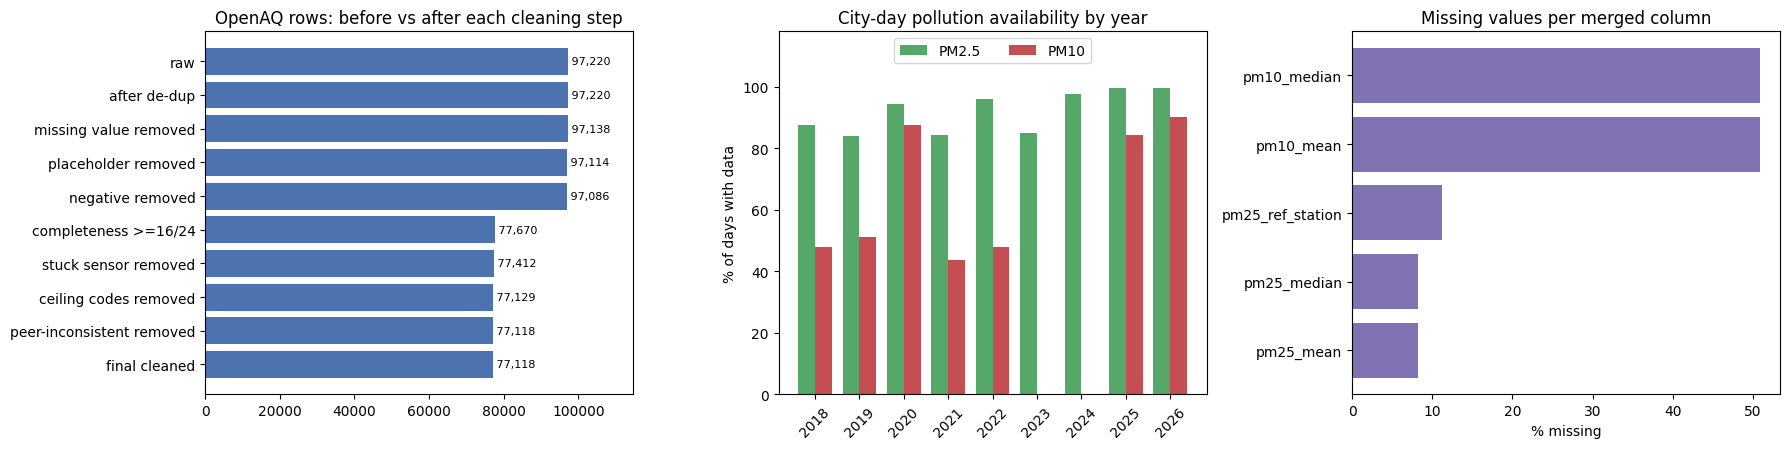

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))
tr = pd.DataFrame(row_trace, columns=["stage", "rows"])
ax[0].barh(tr.stage[::-1], tr.rows[::-1], color="#4c72b0")
for i, v in enumerate(tr.rows[::-1]): ax[0].text(v, i, f" {v:,}", va="center", fontsize=8)
ax[0].set_title("OpenAQ rows: before vs after each cleaning step"); ax[0].set_xlim(0, tr.rows.max() * 1.18)

x = np.arange(len(yr)); w_ = 0.38
ax[1].bar(x - w_/2, yr["pm25_coverage_%"], w_, label="PM2.5", color="#55a868")
ax[1].bar(x + w_/2, yr["pm10_coverage_%"], w_, label="PM10", color="#c44e52")
ax[1].set_xticks(x); ax[1].set_xticklabels(yr.index, rotation=45); ax[1].set_ylabel("% of days with data")
ax[1].set_title("City-day pollution availability by year"); ax[1].legend(loc="upper center", ncol=2); ax[1].set_ylim(0, 118)

m = merged.isna().mean().mul(100); m = m[m > 0]
if len(m): ax[2].barh(m.index, m.values, color="#8172b3"); ax[2].set_xlabel("% missing")
else: ax[2].text(.5, .5, "no missing values", ha="center")
ax[2].set_title("Missing values per merged column")
plt.tight_layout(); plt.show()

## AQI decision (investigated, deliberately **not** calculated)
CPCB's National AQI is built from up to eight pollutants. According to the CPCB methodology (as published through Government of India sources — Arthapedia/IES `ies.gov.in/arthapedia/concept/national-air-quality-index`, the CPCB/IIT Kanpur *National Air Quality Index* report `smartnet.niua.org/.../Air Quality Index.pdf`, and the CAG audit report `saiindia.gov.in/...6-Chapter-2...pdf` which cites CPCB norms):
- a **sub-index needs ≥ 16 hours of data** in the day, and
- the **overall AQI is computed only if ≥ 3 pollutants are available, one of them PM2.5 or PM10**; the overall AQI is the worst sub-index.

This project's data contain only PM2.5 and PM10, so the **official CPCB AQI cannot be computed**. A PM-only number would be an approximation, and whether the project needs one — and which pollutant it should be based on — is a *target-definition* decision that belongs to M4, so M2 does not add it. One data fact M4 will need: PM10 has **no data at all in 2023–2024** and is missing on about half of all days, whereas PM2.5 exists on nearly every day, so any index meant to mean the same thing across years can only rest on PM2.5. (The 16-hour rule above is the part of CPCB methodology M2 *did* use, for completeness filtering.)

In [18]:
available_pollutants = sorted(oq_raw["parameter"].str.lower().unique())
official_possible = len(available_pollutants) >= 3
print("Pollutants available in the data:", available_pollutants)
print("Official CPCB AQI computable (needs >=3 pollutants incl. a PM)?", official_possible)
print("Any AQI column in merged dataset?", any("aqi" in c.lower() for c in merged.columns))

Pollutants available in the data: ['pm10', 'pm25']
Official CPCB AQI computable (needs >=3 pollutants incl. a PM)? False
Any AQI column in merged dataset? False


## 11. Final dataset summary and output files
Writes `merged_daily_clean_m2.csv` (primary hand-over), `M2_cleaning_log.csv`, `M2_data_dictionary.csv`, a supporting `station_day_clean_m2.csv` (the station-day step requested in Section 5; not an alternative final dataset) and `M2_report.md`.

In [19]:
def dtype_label(s):
    t = str(s.dtype)
    return {"datetime64[ns]": "date", "datetime64[us]": "date", "int64": "integer", "Int64": "integer", "float64": "float", "object": "text", "str": "text"}.get(t, t)

DESC = {
 "date": ("Calendar day (merge key), one row per day", "YYYY-MM-DD", "Weather/calendar files (key)"),
 "pm25_mean": ("Mean of Delhi station-day PM2.5 values", "µg/m³", "OpenAQ sensor-days (cleaned, aggregated)"),
 "pm25_median": ("Median of Delhi station-day PM2.5 values", "µg/m³", "OpenAQ sensor-days (cleaned, aggregated)"),
 "pm25_n_stations": ("Number of Delhi stations contributing PM2.5 that day (0 = no data)", "count", "OpenAQ sensor-days (cleaned, aggregated)"),
 "pm25_n_extreme_flagged": ("Quality flag: how many contributing Delhi station-days were flagged extreme (above the 99.9th percentile of PM2.5); values are kept", "count", "OpenAQ sensor-days (cleaned, aggregated)"),
 "pm10_n_extreme_flagged": ("Quality flag: how many contributing Delhi station-days were flagged extreme (above the 99.9th percentile of PM10); values are kept", "count", "OpenAQ sensor-days (cleaned, aggregated)"),
 "pm25_ref_station": ("PM2.5 daily value of the single long-running reference station (the only one reporting in every year; no PM10 exists for it). Validated against the multi-station mean; level is ~8% lower", "µg/m³", "OpenAQ sensor-days (cleaned), reference station"),
 "pm10_mean": ("Mean of Delhi station-day PM10 values", "µg/m³", "OpenAQ sensor-days (cleaned, aggregated)"),
 "pm10_median": ("Median of Delhi station-day PM10 values", "µg/m³", "OpenAQ sensor-days (cleaned, aggregated)"),
 "pm10_n_stations": ("Number of Delhi stations contributing PM10 that day (0 = no data)", "count", "OpenAQ sensor-days (cleaned, aggregated)"),
 "temp_mean": ("Daily mean air temperature", "°C (not stated in file; confirmed only by plausible ranges)", "Open-Meteo weather_daily.csv"),
 "temp_min": ("Daily minimum air temperature", "°C (assumed)", "Open-Meteo weather_daily.csv"),
 "temp_max": ("Daily maximum air temperature", "°C (assumed)", "Open-Meteo weather_daily.csv"),
 "humidity_mean": ("Daily mean relative humidity", "% (assumed)", "Open-Meteo weather_daily.csv"),
 "dewpoint_mean": ("Daily mean dew-point temperature", "°C (assumed)", "Open-Meteo weather_daily.csv"),
 "wind_speed_mean": ("Daily mean wind speed", "m/s (not stated in file; mean 2.5 / max 6.4 would be implausibly calm in km/h) - verify windspeed_unit in your API call", "Open-Meteo weather_daily.csv"),
 "wind_gust_max": ("Daily maximum wind gust", "m/s, same unit as wind_speed_mean", "Open-Meteo weather_daily.csv"),
 "pressure_mean": ("Daily mean air pressure", "hPa (assumed)", "Open-Meteo weather_daily.csv"),
 "precip_sum": ("Daily total precipitation", "mm (assumed)", "Open-Meteo weather_daily.csv"),
 "cloud_mean": ("Daily mean cloud cover", "% (assumed)", "Open-Meteo weather_daily.csv"),
 "wind_dir_deg": ("Daily mean wind direction", "degrees (0-360)", "Open-Meteo weather_daily.csv"),
 "month": ("Month number 1-12", "month", "Festival/calendar file"),
 "day_of_week": ("Day of week, Monday=0 ... Sunday=6", "index", "Festival/calendar file"),
 "is_weekend": ("1 if Saturday/Sunday else 0", "flag 0/1", "Festival/calendar file"),
 "season": ("Season label: winter (Jan-Feb), pre_monsoon (Mar-May), monsoon (Jun-Sep), post_monsoon (Oct-Dec)", "category", "Festival/calendar file"),
 "days_from_diwali": ("Signed days to the nearest Diwali listed in the file (0 = Diwali day)", "days", "Festival/calendar file"),
 "is_festival_window": ("1 if within +/-5 days of a listed Diwali else 0 (Diwali is the only festival encoded)", "flag 0/1", "Festival/calendar file"),
}
data_dictionary = pd.DataFrame([{"column_name": c, "description": DESC[c][0], "data_type": dtype_label(merged[c]), "unit": DESC[c][1], "source": DESC[c][2]} for c in merged.columns])
assert set(merged.columns) == set(DESC), set(merged.columns) ^ set(DESC)

log_df = pd.DataFrame(cleaning_log)
final_path = OUT_DIR / "merged_daily_clean_m2.csv"
merged.to_csv(final_path, index=False, date_format="%Y-%m-%d")
log_df.to_csv(OUT_DIR / "M2_cleaning_log.csv", index=False)
data_dictionary.to_csv(OUT_DIR / "M2_data_dictionary.csv", index=False)
sd_out = station_day.copy()
sd_out.to_csv(OUT_DIR / "station_day_clean_m2.csv", index=False, date_format="%Y-%m-%d")
print("Written:", [p.name for p in [final_path, OUT_DIR / 'M2_cleaning_log.csv', OUT_DIR / 'M2_data_dictionary.csv', OUT_DIR / 'station_day_clean_m2.csv']])
log_df

Written: ['merged_daily_clean_m2.csv', 'M2_cleaning_log.csv', 'M2_data_dictionary.csv', 'station_day_clean_m2.csv']


,cleaning_step,dataset_affected,rows_before,rows_after,rows_removed_or_changed,reason,justification
0,Standardise dtypes and strings,OpenAQ sensor-days,97220,97220,0,date was text; parameter/name strings need to ...,Proper datetime keys are needed for merging; a...
1,Drop exact duplicate rows,OpenAQ sensor-days,97220,97220,0,duplicate rows,Identical rows add no information
2,Drop duplicate sensor-date-parameter keys,OpenAQ sensor-days,97220,97220,0,same sensor/day recorded twice,One value per sensor-day is required before ag...
3,Drop rows with missing daily mean,OpenAQ sensor-days,97220,97138,82,value_avg is NaN,No measurement exists; imputing would fabricat...
4,Drop placeholder-contaminated days (min<=-9999...,OpenAQ sensor-days,97138,97114,24,sensor error codes (-9999 / 9999.9) were avera...,The daily mean is arithmetically contaminated ...
5,Drop negative daily mean,OpenAQ sensor-days,97114,97086,28,negative PM concentration is physically imposs...,Clearly invalid values removed; extreme POSITI...
6,Flag negative hourly minimum (kept),OpenAQ sensor-days,97086,97086,602,min < 0 while daily mean >= 0,Daily mean is valid; flag lets downstream user...
7,Flag sub-hourly sensor-days (kept),OpenAQ sensor-days,97086,97086,34483,observed_count > expected_count (percent_compl...,Sensor reports more often than hourly; raw per...
8,Drop incomplete sensor-days (<16 of 24 expecte...,OpenAQ sensor-days,97086,77670,19416,fewer than 16 readings in the day,CPCB National AQI requires >=16 h of data for ...
9,Drop stuck-sensor days (min == max over >=16 r...,OpenAQ sensor-days,77670,77412,258,all readings identical (of which 217 are exact...,Ambient PM cannot be constant for a day; zero ...


In [20]:
data_dictionary

,column_name,description,data_type,unit,source
0,date,"Calendar day (merge key), one row per day",date,YYYY-MM-DD,Weather/calendar files (key)
1,pm25_mean,Mean of Delhi station-day PM2.5 values,float,µg/m³,"OpenAQ sensor-days (cleaned, aggregated)"
2,pm25_median,Median of Delhi station-day PM2.5 values,float,µg/m³,"OpenAQ sensor-days (cleaned, aggregated)"
3,pm25_n_stations,Number of Delhi stations contributing PM2.5 th...,integer,count,"OpenAQ sensor-days (cleaned, aggregated)"
4,pm25_n_extreme_flagged,Quality flag: how many contributing Delhi stat...,integer,count,"OpenAQ sensor-days (cleaned, aggregated)"
5,pm25_ref_station,PM2.5 daily value of the single long-running r...,float,µg/m³,"OpenAQ sensor-days (cleaned), reference station"
6,pm10_mean,Mean of Delhi station-day PM10 values,float,µg/m³,"OpenAQ sensor-days (cleaned, aggregated)"
7,pm10_median,Median of Delhi station-day PM10 values,float,µg/m³,"OpenAQ sensor-days (cleaned, aggregated)"
8,pm10_n_stations,Number of Delhi stations contributing PM10 tha...,integer,count,"OpenAQ sensor-days (cleaned, aggregated)"
9,pm10_n_extreme_flagged,Quality flag: how many contributing Delhi stat...,integer,count,"OpenAQ sensor-days (cleaned, aggregated)"


## 12. Limitations
The statements below are generated from the data, so the numbers are always current.

In [21]:
yrs_low = yr[yr["pm25_coverage_%"] < 80].index.tolist()
yrs_one = yr[yr["max_pm25_stations"] <= 1].index.tolist()
lim = [
 f"Pollution coverage is uneven: PM2.5 exists on {int(merged.pm25_mean.notna().sum())} of {len(merged)} days; the longest gap with no PM2.5 is {int(gaps['size'].max())} days ({gaps['min'].iloc[0].date()} to {gaps['max'].iloc[0].date()}).",
 f"Years with < 80% PM2.5 day-coverage: {yrs_low if yrs_low else 'none'}. Years where at most 1 station reported: {yrs_one if yrs_one else 'none'} (a 1-station 'city mean' is not comparable with a 30-station one - use *_n_stations).",
 f"Typical stations per day are low in several years: median PM2.5 stations/day by year = {yr['median_pm25_stations'].astype(int).to_dict()}; {int((merged.pm25_n_stations == 1).sum())} days rest on exactly one station. Highest city PM2.5 days: {', '.join(str(d.date()) + ' (' + str(round(v)) + ', n=' + str(n) + ')' for d, v, n in merged.nlargest(3, 'pm25_mean')[['date','pm25_mean','pm25_n_stations']].itertuples(index=False))}.",
 f"PM10 is much sparser than PM2.5: {int(merged.pm10_mean.isna().sum())} of {len(merged)} days missing ({merged.pm10_mean.isna().mean()*100:.1f}%); years with zero PM10 days: {yr.index[yr.pm10_days == 0].tolist()} (only a PM2.5-only station was active).",
 f"The station network changes over time (stations active per year: {yr['max_pm25_stations'].astype(int).to_dict()}), so city averages mix different station sets (compositional bias).",
 f"Rows dropped for <16 readings: {int(log_df.loc[log_df.cleaning_step.str.startswith('Drop incomplete'), 'rows_removed_or_changed'].iloc[0])}. Sub-hourly sensors ({int(oq.flag_subhourly.sum())} kept sensor-days) may reach 16 readings in under 16 hours.",
 f"Flagged but kept: extreme positives {int(oq.flag_extreme.sum())}, peer-suspect days {int(oq.flag_peer_suspect.sum())}, negative hourly minima {int(oq.flag_neg_hourly_min.sum())}, PM2.5>PM10 station-days {int(station_day.flag_pm25_gt_pm10.sum())}. The extreme flag is statistical (99.9th percentile), not an official limit.",
 "Only PM2.5/PM10 are available, so the official CPCB AQI cannot be computed; no AQI column was created.",
 "Weather is a single daily series (one location) and units are not stored in the file; the dictionary lists assumed units that M2 should confirm against the Open-Meteo request.",
 "Calendar encodes Diwali only (window +/-5 days); days_from_diwali is now measured to the nearest of Diwali 2017-2026 (the 2017 and 2026 dates were added by M2). Other festivals are not represented.",
 f"Reference series pm25_ref_station comes from one station (id {REF_ID}); its level is about {round((1-ref_ratio10)*100)}% below the multi-station mean (ratio {ref_ratio10}) but correlation is {ref_corr10}. It has no PM10. Whether the OpenAQ 'New Delhi' feed is the US Embassy monitor cannot be confirmed from the files (coordinates only).",
 f"The source file itself has {len(thin_months)} months with <=1 Delhi PM2.5 station ({thin_months.index.astype(str)[0]} ... {thin_months.index.astype(str)[-1]}); this is missing source data that no cleaning rule can recover.",
 f"{len(excluded)} non-Delhi stations ({', '.join(excluded)}) are in the station-day file but excluded from the city aggregate.",
]
for i, t in enumerate(lim, 1): print(f"{i}. {t}\n")

1. Pollution coverage is uneven: PM2.5 exists on 2933 of 3195 days; the longest gap with no PM2.5 is 32 days (2019-02-15 to 2019-03-18).

2. Years with < 80% PM2.5 day-coverage: none. Years where at most 1 station reported: [2023, 2024] (a 1-station 'city mean' is not comparable with a 30-station one - use *_n_stations).

3. Typical stations per day are low in several years: median PM2.5 stations/day by year = {2018: 1, 2019: 7, 2020: 17, 2021: 1, 2022: 1, 2023: 1, 2024: 1, 2025: 31, 2026: 31}; 1362 days rest on exactly one station. Highest city PM2.5 days: 2019-11-03 (525, n=1), 2018-11-08 (510, n=19), 2021-11-05 (476, n=26).

4. PM10 is much sparser than PM2.5: 1624 of 3195 days missing (50.8%); years with zero PM10 days: [2023, 2024] (only a PM2.5-only station was active).

5. The station network changes over time (stations active per year: {2018: 28, 2019: 28, 2020: 27, 2021: 27, 2022: 27, 2023: 1, 2024: 1, 2025: 33, 2026: 33}), so city averages mix different station sets (composit

## 13. Handoff to M3 / M4
**File to use:** `merged_daily_clean_m2.csv` — one row per day, no duplicate dates, pollution gaps preserved as missing.

| Column group | Columns |
|---|---|
| Key | `date` |
| Pollution (µg/m³) | `pm25_mean`, `pm25_median`, `pm25_n_stations`, `pm25_n_extreme_flagged`, `pm25_ref_station`, `pm10_mean`, `pm10_median`, `pm10_n_stations`, `pm10_n_extreme_flagged` |
| Weather | `temp_mean`, `temp_min`, `temp_max`, `humidity_mean`, `dewpoint_mean`, `wind_speed_mean`, `wind_gust_max`, `pressure_mean`, `precip_sum`, `cloud_mean`, `wind_dir_deg` |
| Calendar | `month`, `day_of_week`, `is_weekend`, `season`, `days_from_diwali`, `is_festival_window` |

**For M3 / M4 to decide (M2 did not):** which pollutant/aggregate is the target (city mean, median, or the single-station `pm25_ref_station`, which runs at a different level from the city mean but correlates strongly — see 5b); whether to require `pm25_n_stations >= 3` as a reliability rule (check how many days per year survive — Section 10 and the 4b table); how to treat the multi-year pollution gap; whether to build a PM-based AQI approximation; how to split train/test given the gap; all lag/rolling features.

In [22]:
# ---------- decisions taken on the external review, with the evidence computed above ----------
def _n(prefix): return int(log_df.loc[log_df.cleaning_step.str.startswith(prefix), "rows_removed_or_changed"].iloc[0])
n_cap = len(cap_hits); n_cap_removed = int((~cap_hits.kept_by_rules).sum())
review_tbl = pd.DataFrame([
 ["1. Add AQI and a high_risk target", "NOT done (M4 scope)", "Target definition and AQI belong to M4 per your brief; official CPCB AQI is not computable from PM2.5/PM10 only"],
 ["2. Pollution not comparable across years", "Diagnosed; partly accepted", f"Confirmed, not an artefact: share of 2021 days with >=3 Delhi stations is {stage_tbl.loc[2021, ('raw file (any value)', 'pct_days_ge3_stations')]}% in the raw file and {stage_tbl.loc[2021, ('after 16-reading rule', 'pct_days_ge3_stations')]}% after the 16-reading rule; 2023-24 rest on one station because the source has {len(thin_months)} thin months (<=1 Delhi station). Looser thresholds recover only part. Added pm25_ref_station (Pearson {ref_corr10}, median level ratio {ref_ratio10}); n>=3 filtering left to M4 via pm25_n_stations"],
 ["3. Exact zeros kept", "Accepted", f"{n_stuck_zero} zero days dropped: all had min=max=0 over >=16 readings while the median of other sensors on those dates was {stuck_zero_peer:.0f} ug/m3"],
 ["4. Implausible extremes kept", "Accepted, different method", f"Dropped {_n('Drop days containing an analyzer ceiling code')} ceiling-code days and {_n('Drop peer-inconsistent')} peer-inconsistent days; a blanket 1000 cap would hit {n_cap} rows of which rules already removed {n_cap_removed} and would miss {n_ceil_below_cap} saturation days whose mean is below 1000"],
 ["5. PM2.5-only AQI for consistency", "Noted for M4", f"PM10 has {int((yr.pm10_days == 0).sum())} years with zero days ({yr.index[yr.pm10_days == 0].tolist()}) and {merged.pm10_mean.isna().mean()*100:.1f}% missing overall; recorded in the handoff"],
 ["6. Duplicate station feeds", "Checked - no issue", f"{len(dup_in_data)} station pairs <500 m among the stations in the sensor data; duplicate ids exist only in openaq_locations.csv"],
 ["7. days_from_diwali wrong at edges", "Accepted", f"Rule reproduced the file with 0 mismatches, then added 2017-10-19 and 2026-11-08; {n_diwali_changed} rows changed"],
 ["8a. Sub-hourly sensors", "Diagnostic only", f"{len(post16) - len(strict)} of {len(post16)} kept sensor-days would fail a 32-reading rule, but sampling cadence is not stated in the file, so the rule is not imposed; flags kept"],
 ["8b. Rename calendar file / ISO dates / units", "Done / verified", "Both file names accepted; all source dates verified ISO yyyy-mm-dd; units updated in the dictionary (plausibility-checked, not stated in the files)"],
], columns=["review point", "decision", "evidence from this notebook"])
pd.set_option("display.max_colwidth", 200)
print(review_tbl.to_string(index=False))

# ---------- generate M2_report.md from the executed variables ----------
def md_table(df):
    d = df.copy()
    cols = [str(c) for c in d.columns]
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in d.iterrows():
        lines.append("| " + " | ".join(str(v).replace("|", "/") for v in r.values) + " |")
    return "\n".join(lines)

removed = log_df[(log_df.rows_after < log_df.rows_before) & (log_df.dataset_affected == "OpenAQ sensor-days")][["cleaning_step", "rows_before", "rows_after", "rows_removed_or_changed"]]
miss_tbl = miss[miss.missing > 0].reset_index().rename(columns={"index": "column"})
report = f'''# M2 Report - Cleaning, Preprocessing and Merging

*Generated by `M2_cleaning_preprocessing_merging.ipynb`; every number comes from the executed notebook.*

## 1. Datasets used and size before cleaning
{md_table(raw_sizes.reset_index().rename(columns={"index": "dataset"}))}

## 2. Data-quality problems found (OpenAQ)
- Missing daily means: {issues['oq_missing_value_avg']}
- Negative daily means: {issues['oq_negative_value_avg']}; days with placeholder codes (-9999 / 9999.9) in min/max: {issues['oq_sentinel_rows']}
- Days with negative hourly minimum but non-negative mean: {issues['oq_negative_hourly_min_but_avg_nonneg']}; exact-zero daily means: {issues['oq_zero_value_avg']}
- Days with fewer than 16 of 24 expected readings: {issues['oq_obs_lt_16']}; days with more readings than expected (sub-hourly sensors): {issues['oq_obs_gt_expected']}
- Duplicate rows: {issues['oq_dup_full_rows']}; duplicate sensor-date keys: {issues['oq_dup_sensor_date_keys']}
- `sd` column unusable (values > 1e4: {issues['oq_sd_gt_1e4']})
- Stuck-sensor days (min == max): {_n('Drop stuck')}; analyzer ceiling-code days: {_n('Drop days containing')}; peer-inconsistent days: {_n('Drop peer-inconsistent')}
- Weather: {int(wx_invalid.sum())} range violations, {len(missing_dates)} missing dates. Calendar: all derived columns consistent with the date.

## 3. Cleaning steps and justification (rows removed)
{md_table(removed)}

Note: {issues["oq_negative_value_avg"]} raw negative daily means exist; {int(log_df.loc[log_df.cleaning_step.str.startswith("Drop negative"), "rows_removed_or_changed"].iloc[0])} were removed by the negative rule and the rest were already removed by the placeholder rule. Aggregation steps (station-day, city-day) are described in section 4. Full list with reasons and justifications: `M2_cleaning_log.csv`. OpenAQ rows: {len(oq_raw)} raw -> {len(oq)} cleaned.

## 4. Pollution aggregation
raw sensor-day rows ({len(oq)}) -> station-day ({len(station_day)} rows; mean of sensor means, lossless because groups with >1 sensor = {overlap_groups}) -> city-day ({len(city)} dates; mean and median across {int(st.in_city_aggregate.sum())} Delhi stations, with station counts). Non-Delhi stations excluded from city mean: {', '.join(excluded)}.

## 5. Weather preprocessing
Date parsed, uniqueness and continuity checked, physical-range rules applied (0 violations), constant `hours` column dropped after confirming every day has 24 hours. No lag or rolling features.

## 6. Festival/calendar preprocessing
Date parsed, month/weekday/weekend/season/festival-window validated against the date; `days_from_diwali` cast to integer. Only Diwali is encoded.

## 7. Merge methodology
weather join calendar on `date` (one-to-one, outer, all days matched) then left-join city-day pollution on `date` (one-to-one). Missing pollution days are kept as missing. All validation checks passed (alignment of weather, calendar and pollution by date; no duplicate keys or rows).

## 8. Final dataset
- Size: {merged.shape[0]} rows x {merged.shape[1]} columns
- Date range: {merged.date.min().date()} to {merged.date.max().date()}
- Duplicate rows: {int(merged.duplicated().sum())}; duplicate dates: {int(merged.date.duplicated().sum())}
- PM2.5 days available: {int(merged.pm25_mean.notna().sum())} (missing {int(merged.pm25_mean.isna().sum())}); PM10 days available: {int(merged.pm10_mean.notna().sum())} (missing {int(merged.pm10_mean.isna().sum())})

Missing values:
{md_table(miss_tbl)}

Coverage by year:
{md_table(yr.reset_index()[["year","days_in_data","pm25_days","pm25_missing_days","pm25_coverage_%","pm10_days","pm10_coverage_%","max_pm25_stations"]])}

## 9. Important limitations
''' + "\n".join(f"{i}. {t}" for i, t in enumerate(lim, 1)) + f'''

## 10. Final columns
{", ".join(merged.columns)}

## 10b. Review feedback: diagnosis and decisions
{md_table(review_tbl)}

## 11. Handed over to M3 / M4
`merged_daily_clean_m2.csv` (primary), `M2_cleaning_log.csv`, `M2_data_dictionary.csv`, plus supporting `station_day_clean_m2.csv`. AQI: official CPCB AQI not computable (only PM2.5/PM10 available); target definition, pollutant choice, gap handling and all features are left to M3/M4.
'''
(OUT_DIR / "M2_report.md").write_text(report, encoding="utf-8")
print("report written:", (OUT_DIR / "M2_report.md").name, "|", len(report.splitlines()), "lines")

                                review point                   decision                                                                                                                                                                                                                                                                                                                                                      evidence from this notebook
           1. Add AQI and a high_risk target        NOT done (M4 scope)                                                                                                                                                                                                                                                                  Target definition and AQI belong to M4 per your brief; official CPCB AQI is not computable from PM2.5/PM10 only
    2. Pollution not comparable across years Diagnosed; partly accepted Confirmed, not an artefact: share of 2021 days

In [23]:
# ---------- FINAL VERIFICATION: reload every output from disk ----------
for f in ["merged_daily_clean_m2.csv", "M2_cleaning_log.csv", "M2_data_dictionary.csv", "station_day_clean_m2.csv", "M2_report.md"]:
    p = OUT_DIR / f
    print(f"{f:32s} exists={p.exists()}  size={p.stat().st_size:,} bytes")
    assert p.exists() and p.stat().st_size > 0

chk_df = pd.read_csv(OUT_DIR / "merged_daily_clean_m2.csv", parse_dates=["date"])
print("\nReloaded merged_daily_clean_m2.csv")
print("shape        :", chk_df.shape)
print("columns      :", chk_df.columns.tolist())
print("date range   :", chk_df.date.min().date(), "->", chk_df.date.max().date())
print("duplicate rows:", int(chk_df.duplicated().sum()), "| duplicate dates:", int(chk_df.date.duplicated().sum()))
print("missing values:"); print(chk_df.isna().sum()[chk_df.isna().sum() > 0].to_string())
assert chk_df.shape == merged.shape and chk_df.date.is_unique and chk_df.duplicated().sum() == 0
print("\nCSV reloads successfully; no duplicate rows or dates introduced by the merge.")
print("Log rows:", len(pd.read_csv(OUT_DIR / "M2_cleaning_log.csv")), "| dictionary rows:", len(pd.read_csv(OUT_DIR / "M2_data_dictionary.csv")))

merged_daily_clean_m2.csv        exists=True  size=607,873 bytes
M2_cleaning_log.csv              exists=True  size=7,183 bytes
M2_data_dictionary.csv           exists=True  size=3,317 bytes
station_day_clean_m2.csv         exists=True  size=4,134,716 bytes
M2_report.md                     exists=True  size=9,550 bytes

Reloaded merged_daily_clean_m2.csv
shape        : (3195, 27)
columns      : ['date', 'pm25_mean', 'pm25_median', 'pm25_n_stations', 'pm25_n_extreme_flagged', 'pm25_ref_station', 'pm10_mean', 'pm10_median', 'pm10_n_stations', 'pm10_n_extreme_flagged', 'temp_mean', 'temp_min', 'temp_max', 'humidity_mean', 'dewpoint_mean', 'wind_speed_mean', 'wind_gust_max', 'pressure_mean', 'precip_sum', 'cloud_mean', 'wind_dir_deg', 'month', 'day_of_week', 'is_weekend', 'season', 'days_from_diwali', 'is_festival_window']
date range   : 2018-01-01 -> 2026-09-30
duplicate rows: 0 | duplicate dates: 0
missing values:
pm25_mean            262
pm25_median          262
pm25_ref_station     359